# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version (Fixed) — Multi-Seed SAC + Ablation Study + XAI Analysis

**Ringkasan perbaikan dari versi sebelumnya:**
- Duplikasi definisi fungsi dihapus (tiap fungsi hanya didefinisikan sekali)
- Cache key diubah ke tuple `('train', i)` / `('test', i)` agar tidak collision
- `compute_market_features`: parameter `port_val` yang tidak dipakai dihapus
- `_solve_weights`: menambahkan `warnings.warn` saat fallback ke equal-weight
- `get_obs_dim` & `build_observation`: konsisten — raise `ValueError` jika keduanya False
- `AblationPortfolioEnv`: `_rew_stats` di-reset tiap `reset()` (bukan akumulasi lintas episode)
- `AblationPortfolioEnv`: parameter `split='train'/'test'` menggantikan `data_start_offset` integer
- `run_wilcoxon_tests` sekarang dipanggil di Final Analysis dan hasilnya ditampilkan
- Label `Features` di dashboard diperbaiki: `Network(2) + Market(7)` (bukan 5+4)
- `FEATURE_NAMES` dikelompokkan dengan komentar agar sesuai implementasi
- `plot_shap_analysis`: background & explain sample diperbesar; skip jika model None
- Judul notebook disesuaikan: CVaR adalah metrik evaluasi, bukan reward RL


## 1. Imports & Global Settings

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import shap
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from tqdm.notebook import tqdm
from scipy import stats
from scipy.optimize import minimize
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 30000
FORCE_RETRAIN = True    # Set False jika model sudah ada
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95    # CVaR digunakan sebagai metrik evaluasi, bukan reward
STAT_ALPHA    = 0.05
SAVE_IMAGES   = False

ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'is_ensemble': True},
    #'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'static_gamma': 0.0},
    #'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'static_gamma': 2.0},
    # Buy-and-Hold: gamma awal dihitung satu kali, tidak di-update tiap step
    'BuyHold_Markowitz'  : {'use_network': True,  'use_market': False, 'is_buyhold': True},
    'EqualWeight'        : {'is_equal_weight': True},
}

EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

SCRIPT_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'ablation_results_thesis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment initialized.')
print(f'Output dir: {OUTPUT_DIR}')



Environment initialized.
Output dir: g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean2\ablation_results_thesis


## 2. Data Loading

In [2]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets  : {len(assets)} — {assets}')
print(f'Training: {ret_train.index[0].date()} to {ret_train.index[-1].date()} ({len(ret_train)} rows)')
print(f'Testing : {ret_test.index[0].date()} to {ret_test.index[-1].date()} ({len(ret_test)} rows)')


Assets  : 9 — ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training: 2017-09-15 to 2019-03-02 (534 rows)
Testing : 2019-03-03 to 2019-10-17 (229 rows)


## 3. Portfolio Optimization Logic

In [3]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory denoising filter pada correlation matrix."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """
    Minimisasi: w^T * cov_f * w + gamma * cent_vec^T * w
    subject to: sum(w)=1, long-only, dan opsional return constraint.
    FIX: menambahkan warning eksplisit saat fallback ke equal-weight.
    """
    fun    = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    w0     = np.ones(n_assets) / n_assets
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    if res2.success:
        return res2.x
    # FIX: warn secara eksplisit — jangan diam-diam fallback
    warnings.warn(
        f'Optimization failed (gamma={gamma:.3f}). Falling back to equal-weight.',
        RuntimeWarning, stacklevel=2
    )
    return w0


def _build_mst_centrality(N, corr_f):
    """Bangun MST dari RMT-denoised correlation matrix, hitung eigenvector centrality."""
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


def compute_classic_mv_weights(returns_window):
    """Mean-Variance klasik Markowitz sebagai baseline."""
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun    = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


## 4. Metrics & Helpers

In [4]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return dd, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n   = len(arr)
    if n == 0:
        return np.nan
    total = (1 + arr).prod()
    if total <= 0:
        return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr      = np.array(ret_series)
    ann_ret  = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0:
        return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    dd, _   = _compute_drawdown(arr)
    max_dd  = dd.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0


def calculate_cvar(ret_series, confidence=0.95):
    """Conditional Value-at-Risk (CVaR / Expected Shortfall).
    Digunakan sebagai metrik EVALUASI, bukan sebagai fungsi reward RL."""
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    var         = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    return float(-np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0


def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd ** 2)))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    dd, _   = _compute_drawdown(arr)
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : (1 + arr).prod() - 1,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Max Drawdown'    : dd.min(),
        'Ulcer Index'     : calculate_ulcer_index(arr),
    }


## 5. Visualization Helpers

In [5]:
ABLATION_COLORS = {
    'E2_Sharpe'          : '#FF0000', # Merah
    'E2_Sortino'         : '#FFD700', # Kuning (Gold)
    'E2_Calmar'          : '#008000', # Hijau
    'E2_Ulcer'           : '#0000FF', # Biru
    'E2_Ensemble_Avg'    : '#800080', # Ungu
    'Comp_Static_Gamma0' : '#FFD700', # Kuning (Dashed)
    'Comp_Static_Gamma1' : '#800080', # Ungu (Dashed)
    'Comp_Static_Gamma2' : '#000000', # Hitam
    'Classic-MV'         : '#FF0000', # Merah (Dashed)
    'BuyHold_Markowitz'  : '#008000', # Hijau (Dashed)
    'EqualWeight'        : '#0000FF', # Biru (Dashed)
}

ABLATION_LINESTYLES = {
    'E2_Sharpe'          : '-',
    'E2_Sortino'         : '-',
    'E2_Calmar'          : '-',
    'E2_Ulcer'           : '-',
    'E2_Ensemble_Avg'    : '-',
    'Comp_Static_Gamma0' : '--',
    'Comp_Static_Gamma1' : '--',
    'Comp_Static_Gamma2' : '-',
    'Classic-MV'         : '--',
    'BuyHold_Markowitz'  : '--',
    'EqualWeight'        : '--',
}


DISPLAY_NAMES = {
    'E2_Sharpe'          : 'E2-Sharpe',
    'E2_Sortino'         : 'E2-Sortino',
    'E2_Calmar'          : 'E2-Calmar',
    'E2_Ulcer'           : 'E2-Ulcer',
    'E2_Ensemble_Avg'    : 'E2-Ensemble',
    'Comp_Static_Gamma0' : 'gamma=0 (Static)',
    'Comp_Static_Gamma1' : 'gamma=1 (Static)',
    'Comp_Static_Gamma2' : 'gamma=2 (Static)',
    'Classic-MV'         : 'Classic-MV',
    'BuyHold_Markowitz'  : 'Buy&Hold-Markowitz',
    'EqualWeight'        : 'Equal-Weight (Reb)',
}

# FIX: 2 network + 7 market = 9 total, sesuai implementasi
FEATURE_NAMES = [
    'MST.Dist x0.1', 'Spectral.Gap',           # network (2)
    'VolShort x100', 'VolLong x100', 'Vol.Ratio',  # market: volatility (3)
    'Mom5d x100', 'Mom20d x100', 'MomCross x100', 'Pct.Uptrend',  # market: momentum (4)
]


def get_display_name(exp_id):
    return DISPLAY_NAMES.get(exp_id, exp_id)


class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards        = []
        self.current_episode_reward = 0.0

    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0.0
        return True


def plot_learning_curves(history_dict):
    plt.figure(figsize=(10, 4))
    for seed, rewards in history_dict.items():
        if len(rewards) == 0:
            continue
        smoothed = pd.Series(rewards).rolling(window=max(1, len(rewards) // 10)).mean()
        plt.plot(smoothed, label=f'seed={seed}', alpha=0.8)
    plt.title(f'SAC Learning Curves - Steps: {TRAIN_STEPS}', fontsize=12, fontweight='bold')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Episode Reward')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150)
    plt.show()
    plt.close()



## 6. Dashboard & Statistical Analysis

In [6]:
def run_wilcoxon_tests(results_dict, baseline_id='Classic-MV'):
    """
    Wilcoxon signed-rank test: tiap eksperimen vs baseline.
    Mengembalikan dict {exp_id: p_value}.
    FIX: mengembalikan dict (bukan string), index disejajarkan sebelum test.
    """
    if baseline_id not in results_dict:
        print('Baseline not found in results.')
        return {}
    baseline_rets = results_dict[baseline_id].mean(axis=1)
    pvalues = {}
    for exp_id, rets_df in results_dict.items():
        if exp_id == baseline_id:
            continue
        exp_rets   = rets_df.mean(axis=1)
        common_idx = baseline_rets.index.intersection(exp_rets.index)
        try:
            _, p = stats.wilcoxon(exp_rets.loc[common_idx], baseline_rets.loc[common_idx])
            pvalues[exp_id] = p
        except Exception:
            pvalues[exp_id] = np.nan
    return pvalues


def generate_dashboard(results_dict, title_prefix, period_name, filename_base):
    exp_ids      = list(results_dict.keys())
    metrics_list = []

    for exp_id in exp_ids:
        rets_df = results_dict[exp_id]
        m_seeds = [calculate_all_metrics(rets_df[s], CVAR_LEVEL) for s in rets_df.columns]
        # FIX: label Features sesuai implementasi (2 network + 7 market)
        feat_label = 'Network(2) + Market(7)' if str(exp_id).startswith('E2') else 'Static / Baseline'
        res = {
            'Experiment': exp_id,
            'Features'  : feat_label,
            'Obs Dim'   : get_obs_dim(ABLATION_CONFIGS[exp_id]) if exp_id in ABLATION_CONFIGS else 0,
        }
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in m_seeds]
            res[f'{m} Mean'] = np.mean(vals)
            res[f'{m} Std']  = np.std(vals)
        res['CVaR Mean'] = np.mean([ms['CVaR (95%)'] for ms in m_seeds])
        res['MaxDD Mean'] = np.mean([ms['Max Drawdown'] for ms in m_seeds])
        metrics_list.append(res)

    df_metrics = pd.DataFrame(metrics_list).sort_values(by='Sharpe Ratio Mean', ascending=False)

    # --- Plot 1: Table + Bar Charts ---
    fig1 = plt.figure(figsize=(16, 10), facecolor='white')
    gs1  = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1.0])
    fig1.suptitle(
        f'{title_prefix} - Metrics Comparison\nSteps: {TRAIN_STEPS}',
        fontsize=14, fontweight='bold', y=0.98
    )

    ax_table = fig1.add_subplot(gs1[0, :])
    ax_table.axis('off')
    columns    = ['Experiment', 'Features', 'Obs Dim',
                  'Sharpe (up)', 'Sortino (up)', 'Calmar (up)', 'Ulcer (down)', 'Rank']
    table_data = []
    for rank, (_, row) in enumerate(df_metrics.iterrows(), 1):
        table_data.append([
            row['Experiment'], row['Features'], row['Obs Dim'],
            f"{row['Sharpe Ratio Mean']:.3f}+/-{row['Sharpe Ratio Std']:.3f}",
            f"{row['Sortino Ratio Mean']:.3f}+/-{row['Sortino Ratio Std']:.3f}",
            f"{row['Calmar Ratio Mean']:.3f}+/-{row['Calmar Ratio Std']:.3f}",
            f"{row['Ulcer Index Mean']:.4f}+/-{row['Ulcer Index Std']:.4f}",
            f'#{rank}',
        ])
    table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    ax_table.set_title('Rangkuman Metrik Performa', fontsize=11, fontweight='bold', pad=15)

    for i, m in enumerate(EVAL_METRICS):
        ax    = fig1.add_subplot(gs1[1, i])
        exps  = [row['Experiment'] for _, row in df_metrics.iterrows()]
        means = [row[f'{m} Mean']   for _, row in df_metrics.iterrows()]
        ax.bar(range(len(exps)), means,
               color=[ABLATION_COLORS.get(e, '#777777') for e in exps])
        ax.set_title(m, fontsize=10, fontweight='bold')
        ax.set_xticks(range(len(exps)))
        ax.set_xticklabels([get_display_name(e) for e in exps],
                           rotation=45, ha='right', fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'1_metrics_{filename_base}'), dpi=200)
    plt.show()
    plt.close()



    # --- Plot 2: Cumulative Returns ---
    plt.figure(figsize=(16, 7), facecolor='white')
    for exp_id in results_dict:
        cum = (1 + results_dict[exp_id].mean(axis=1)).cumprod()
        plt.plot(cum, label=get_display_name(exp_id),
                 color=ABLATION_COLORS.get(exp_id, '#777777'),
                 linestyle=ABLATION_LINESTYLES.get(exp_id, '-'))
    plt.title(f'Cumulative Returns - {period_name} Period - Steps: {TRAIN_STEPS}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'2_returns_{filename_base}'), dpi=200)
    plt.show()
    plt.close()


    # --- Plot 3: Radar / Spider Chart ---
    from matplotlib.patches import FancyArrowPatch
    df_metrics['R_Sharpe']  = df_metrics['Sharpe Ratio Mean'].rank(ascending=False)
    df_metrics['R_Sortino'] = df_metrics['Sortino Ratio Mean'].rank(ascending=False)
    df_metrics['R_Calmar']  = df_metrics['Calmar Ratio Mean'].rank(ascending=False)
    df_metrics['R_CVaR']    = df_metrics['CVaR Mean'].rank(ascending=True)
    df_metrics['R_MaxDD']   = df_metrics['MaxDD Mean'].rank(ascending=False)
    df_metrics['R_Ulcer']   = df_metrics['Ulcer Index Mean'].rank(ascending=True)

    TOP_N   = min(6, len(df_metrics))
    top_ids = df_metrics['Experiment'].values[:TOP_N]
    categories = ['Sharpe','Sortino','Calmar','Ulcer↓','CVaR↓','MaxDD↑']
    N_cat      = len(categories)
    angles     = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
    angles    += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True}, facecolor='white')
    ax.set_facecolor('#f9f9f9')

    n = len(df_metrics)
    for exp_id in top_ids:
        row    = df_metrics[df_metrics['Experiment'] == exp_id].iloc[0]
        vals   = [
            1 - (row['R_Sharpe']  - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Sortino'] - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Calmar']  - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Ulcer']   - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_CVaR']    - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_MaxDD']   - 1) / (n - 1) if n > 1 else 1.0,
        ]
        vals  += vals[:1]
        color  = ABLATION_COLORS.get(exp_id, '#777777')
        ls     = ABLATION_LINESTYLES.get(exp_id, '-')
        ax.plot(angles, vals, color=color, linestyle=ls, linewidth=1.8, label=get_display_name(exp_id))
        if ls == '-':
            ax.fill(angles, vals, color=color, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='grey')
    ax.set_title(f'{title_prefix} - Performance Radar (Top {TOP_N})\nSteps: {TRAIN_STEPS}',
                 fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'3_radar_{filename_base}'), dpi=200)
    plt.show()
    plt.close()




## 7. SHAP Interpretability Analysis

In [7]:
def plot_shap_analysis(model_paths, env, config, exp_id,
                       n_background=100, n_explain=200):
    """
    SHAP analysis untuk model SAC.
    FIX:
    - Sample dikumpulkan dari satu episode penuh (bukan loop reset 50x)
    - n_background & n_explain diperbesar untuk thesis-quality hasil
    - Lewati eksperimen jika model None
    """
    print(f'Generating SHAP analysis for {exp_id}...')
    if isinstance(model_paths, list):
        models = [SAC.load(p) for p in model_paths if p is not None]
    else:
        models = [SAC.load(model_paths)] if model_paths is not None else []

    if len(models) == 0:
        print(f'  Skipped {exp_id}: tidak ada model yang valid.')
        return

    obs_list = []
    obs, _   = env.reset()
    done     = False
    while not done:
        obs_list.append(obs.copy())
        action, _ = models[0].predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)

    n_total = len(obs_list)
    if n_total < n_background + 10:
        print(f'  Warning: hanya {n_total} obs tersedia untuk {exp_id}.')
        n_background = max(10, n_total // 3)
        n_explain    = min(50, n_total - n_background)

    X    = np.array(obs_list)
    feat = FEATURE_NAMES[:X.shape[1]]
    df_X = pd.DataFrame(X, columns=feat)

    def predict_action(x):
        x_t = torch.tensor(np.array(x), dtype=torch.float32)
        with torch.no_grad():
            acts = [m.policy.actor(x_t).numpy() for m in models]
        return np.mean(acts, axis=0)

    background  = df_X.iloc[:n_background]
    explain     = df_X.iloc[n_background:n_background + n_explain]
    explainer   = shap.Explainer(predict_action, background)
    shap_values = explainer(explain)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, explain, show=False)
    plt.title(f'SHAP Feature Importance - {exp_id} - Steps: {TRAIN_STEPS}',
              fontsize=12, fontweight='bold')
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'shap_summary_{exp_id}.png'), dpi=150)
    plt.show()
    plt.close()


## 8. Feature Engineering & Cache

In [8]:
def compute_network_features(returns_window):
    """
    Menghasilkan 2 network features:
      [0] MST total distance * 0.1
      [1] Spectral gap (algebraic connectivity MST)
    """
    T, N  = returns_window.shape
    corr_f = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist     = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window):
    """
    Menghasilkan 7 market features:
      [0] VolShort x100   [1] VolLong x100   [2] Vol.Ratio
      [3] Mom5d x100      [4] Mom20d x100     [5] MomCross x100  [6] Pct.Uptrend
    FIX: parameter port_val yang tidak digunakan dihapus.
    """
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5   = arr[-win5:].std(axis=0).mean()
    v20  = arr[-win20:].std(axis=0).mean()
    m5   = arr[-win5:].mean(axis=0).mean()
    m20  = arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([
        v5 * 100, v20 * 100, v5 / (v20 + 1e-8),
        m5 * 100, m20 * 100, (m5 - m20) * 100, pct_up
    ], dtype=np.float32)


def get_obs_dim(config):
    """
    FIX: raise ValueError jika keduanya False (bukan diam-diam return 1).
    Konsisten dengan build_observation yang juga akan error dalam kasus itu.
    """
    d = 0
    if config.get('use_network', False): d += 2
    if config.get('use_market',  False): d += 7
    
    return d


# ── Precompute Cache ──────────────────────────────────────────────────────
# FIX: key tuple ('train', i) / ('test', i) menggantikan integer offset
# agar tidak ada collision antara index train dan test.
GLOBAL_CACHE = {}

print('Precomputing training cache...')
for i in tqdm(range(SET_WINDOW, len(ret_train))):
    win     = ret_train.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('train', i)] = {
        'win'         : win,
        'corr_f'      : corr,
        'cent_vec'    : cent,
        # cov_f: RMT-denoised pseudo-covariance + regularisasi diagonal
        'cov_f'       : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'          : win.mean().values,
        'nw_feat_full': feat,
    }

print('Precomputing testing cache...')
for i in tqdm(range(SET_WINDOW, len(ret_test))):
    win     = ret_test.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('test', i)] = {
        'win'         : win,
        'corr_f'      : corr,
        'cent_vec'    : cent,
        'cov_f'       : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'          : win.mean().values,
        'nw_feat_full': feat,
    }

# Normalisasi: hanya dari data training (no data leakage ke test)
_train_feats = np.stack([
    GLOBAL_CACHE[('train', i)]['nw_feat_full']
    for i in range(SET_WINDOW, len(ret_train))
])
FEAT_MEAN = _train_feats.mean(axis=0)
FEAT_STD  = _train_feats.std(axis=0) + 1e-8

print(f'Cache siap: {len(GLOBAL_CACHE)} entries')
print(f'  FEAT_MEAN = {FEAT_MEAN}')
print(f'  FEAT_STD  = {FEAT_STD}')


def build_observation(win, config, nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None:
        nw_feat_raw, corr_f, _ = compute_network_features(win)
    obs = []
    if config.get('use_network', False):
        obs.append((nw_feat_raw - FEAT_MEAN) / FEAT_STD)
    if config.get('use_market', False):
        obs.append(compute_market_features(win))
    if len(obs) == 0:
        raise ValueError('build_observation: obs kosong. Aktifkan use_network atau use_market.')
    return np.nan_to_num(np.concatenate(obs)), corr_f



Precomputing training cache...


  0%|          | 0/504 [00:00<?, ?it/s]

Precomputing testing cache...


  0%|          | 0/199 [00:00<?, ?it/s]

Cache siap: 703 entries
  FEAT_MEAN = [0.5158907  0.43588346]
  FEAT_STD  = [0.18963242 0.12605983]


## 9. RL Environment

In [9]:
class AblationPortfolioEnv(gym.Env):
    """
    Gymnasium environment untuk ablation study portfolio optimization.

    Action      : gamma scalar dalam [-5, 5].
    Observation : fitur (network + market) yang telah dinormalisasi.
    Reward      : risk-return metric (Sharpe/Sortino/Calmar/Ulcer),
                  dinormalisasi online Welford per episode.

    FIX:
    - Parameter split='train'/'test' menggantikan data_start_offset integer.
    - _rew_stats di-reset di reset() agar tidak ada bias akumulasi lintas episode.
    """

    def __init__(self, data, config, split='train'):
        super().__init__()
        self.data   = data
        self.config = config
        self.split  = split
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()

        dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _reset_rew_stats(self):
        self._rew_stats = {'mean': 0.0, 'M2': 0.0, 'count': 0}

    def _get_obs(self):
        c = GLOBAL_CACHE[(self.split, self.current_step)]
        obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f'])
        return obs

    def reset(self, seed=None, options=None):
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()  # FIX: reset per episode
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        c     = GLOBAL_CACHE[(self.split, self.current_step)]
        w     = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)

        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW:
            self._returns_buffer.pop(0)

        arr         = np.array(self._returns_buffer)
        reward_type = self.config.get('reward_type', 'calmar')

        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe':
                raw_reward = float(np.clip(calculate_sharpe_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'sortino':
                raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar':
                raw_reward = float(np.clip(calculate_calmar_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'ulcer':
                ann_ret = calculate_annualized_return(arr)
                ulcer   = calculate_ulcer_index(arr)
                raw_reward = float(np.clip(ann_ret / (ulcer + 1e-8), -10.0, 10.0))
            else:
                raw_reward = 0.0

        # Online Welford variance normalization (di-reset per episode)
        s = self._rew_stats
        s['count'] += 1
        delta      = raw_reward - s['mean']
        s['mean'] += delta / s['count']
        s['M2']   += delta * (raw_reward - s['mean'])
        std    = np.sqrt(s['M2'] / s['count']) if s['count'] > 1 else 1.0
        reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))

        self.current_step += 1
        done     = self.current_step >= len(self.data) - 1
        next_obs = (self._get_obs() if not done
                    else np.zeros(self.observation_space.shape, dtype=np.float32))
        return next_obs, reward, done, False, {}


## 10. Training

Experiments:   0%|          | 0/8 [00:00<?, ?it/s]

Seeds for E2_Sharpe:   0%|          | 0/3 [00:00<?, ?it/s]

Output()

Output()

Output()

...

Output()

Seeds for E2_Ulcer:   0%|          | 0/3 [00:00<?, ?it/s]

Output()

Output()

Output()

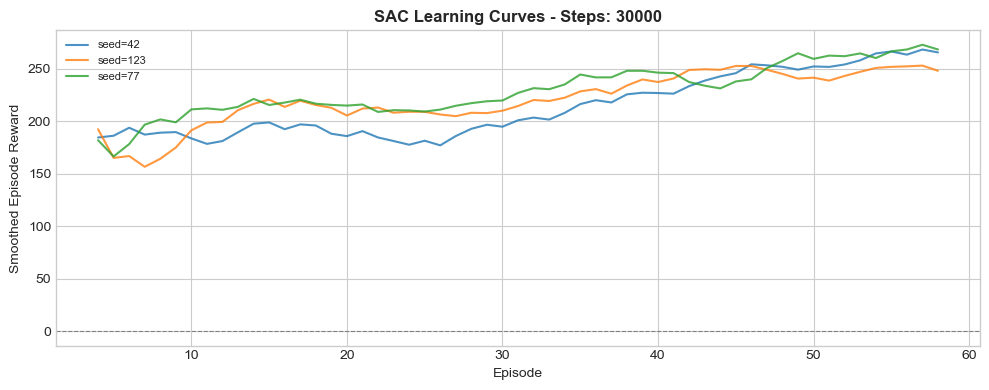

Training selesai.


In [10]:
trained_models  = {}
train_histories = {}

exp_bar = tqdm(ABLATION_CONFIGS.items(), desc='Experiments')
for exp_id, config in exp_bar:
    # Skip static gamma dan ensemble (tidak ada RL training)
    if config.get('static_gamma') is not None or config.get('is_ensemble') or config.get('is_buyhold') or config.get('is_equal_weight'):
        continue

    train_histories[exp_id] = {}
    seed_bar = tqdm(SEEDS, desc=f'Seeds for {exp_id}', leave=False)

    for seed in seed_bar:
        name = f'model_{exp_id}_s{seed}'
        if os.path.exists(name + '.zip') and not FORCE_RETRAIN:
            trained_models[(exp_id, seed)] = name
            print(f'  Loaded existing: {name}')
            continue

        # FIX: split='train' (bukan data_start_offset=0)
        env      = AblationPortfolioEnv(ret_train, config, split='train')
        callback = RewardLoggerCallback()
        model    = SAC('MlpPolicy', env, seed=seed, verbose=0, learning_rate=3e-4)
        model.learn(total_timesteps=TRAIN_STEPS, callback=callback, progress_bar=True)

        model.save(name)
        trained_models[(exp_id, seed)]  = name
        train_histories[exp_id][seed]   = callback.episode_rewards

if 'E2_Sharpe' in train_histories:
    plot_learning_curves(train_histories['E2_Sharpe'])

print('Training selesai.')




## 11. Backtesting Loop

In [11]:
results_test  = {}
results_train = {}

all_exp_ids = list(ABLATION_CONFIGS.keys()) + ['Classic-MV']  # BuyHold_Markowitz sudah ada di ABLATION_CONFIGS

for exp_id in tqdm(all_exp_ids, desc='Backtesting'):
    results_test[exp_id]  = pd.DataFrame()
    results_train[exp_id] = pd.DataFrame()
    config = ABLATION_CONFIGS.get(exp_id, {})

    for seed in SEEDS:
        model           = None
        ensemble_models = []

        if exp_id != 'Classic-MV' and config.get('static_gamma') is None and not config.get('is_buyhold') and not config.get('is_equal_weight'):
            if config.get('is_ensemble'):
                for m_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']:
                    ensemble_models.append(SAC.load(trained_models[(m_id, seed)]))
            else:
                model = SAC.load(trained_models[(exp_id, seed)])

        # ── Buy&Hold-Markowitz: hitung bobot awal sekali, lalu drift ──────────
        if config.get('is_buyhold'):
            def _make_buyhold_rets(data_df, split_key):
                """
                Bobot awal = Markowitz-Centrality dengan gamma=1 pada window pertama.
                Setelah itu bobot dibiarkan drift alami mengikuti harga (no rebalancing).
                Ini mensimulasikan investor yang menentukan alokasi awal menggunakan
                network-Markowitz, lalu tidak melakukan rebalancing sama sekali.
                """
                c0  = GLOBAL_CACHE[(split_key, SET_WINDOW)]
                w   = fast_centrality_weights(c0['cov_f'], c0['cent_vec'],
                                              c0['mu'], gamma=1.0)   # inisialisasi
                rets = []
                for idx in range(SET_WINDOW, len(data_df)):
                    r_vec    = data_df.iloc[idx].values
                    port_ret = float(np.dot(w, r_vec))
                    rets.append(port_ret)
                    # drift: biarkan bobot bergerak mengikuti return aset, tanpa rebalancing
                    w = w * (1 + r_vec)
                    total = w.sum()
                    if total > 1e-10:
                        w = w / total          # normalisasi nilai (bukan rebalancing)
                    else:
                        w = np.ones(len(w)) / len(w)  # fallback jika collapse
                return rets

            rets_test  = _make_buyhold_rets(ret_test,  'test')
            rets_train = _make_buyhold_rets(ret_train, 'train')
            results_test[exp_id][seed]  = pd.Series(rets_test,
                                                     index=ret_test.index[SET_WINDOW:])
            results_train[exp_id][seed] = pd.Series(rets_train,
                                                     index=ret_train.index[SET_WINDOW:])
            continue   # skip sisa loop (tidak perlu get_weights)

        def get_weights(split, step_idx):
            c = GLOBAL_CACHE[(split, step_idx)]
            if exp_id == 'Classic-MV':
                return compute_classic_mv_weights(c['win'])
            if config.get('is_equal_weight'):
                return np.ones(len(assets)) / len(assets)
            if config.get('static_gamma') is not None:
                return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                               c['mu'], config['static_gamma'])
            obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
            if config.get('is_ensemble'):
                gammas = [float(em.predict(obs, deterministic=True)[0][0])
                          for em in ensemble_models]
                return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                               c['mu'], np.mean(gammas))
            action, _ = model.predict(obs, deterministic=True)
            return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                           c['mu'], float(action[0]))

        # --- Testing ---
        rets_test = [
            np.dot(get_weights('test', i), ret_test.iloc[i].values)
            for i in range(SET_WINDOW, len(ret_test))
        ]
        results_test[exp_id][seed] = pd.Series(
            rets_test, index=ret_test.index[SET_WINDOW:])

        # --- Training (evaluasi ulang, bukan training) ---
        rets_train_eval = [
            np.dot(get_weights('train', i), ret_train.iloc[i].values)
            for i in range(SET_WINDOW, len(ret_train))
        ]
        results_train[exp_id][seed] = pd.Series(
            rets_train_eval, index=ret_train.index[SET_WINDOW:])

print('Backtesting selesai.')





Backtesting:   0%|          | 0/9 [00:00<?, ?it/s]

Backtesting selesai.


## 12. Final Analysis, Wilcoxon Tests & SHAP


=== Generating Final Dashboards ===


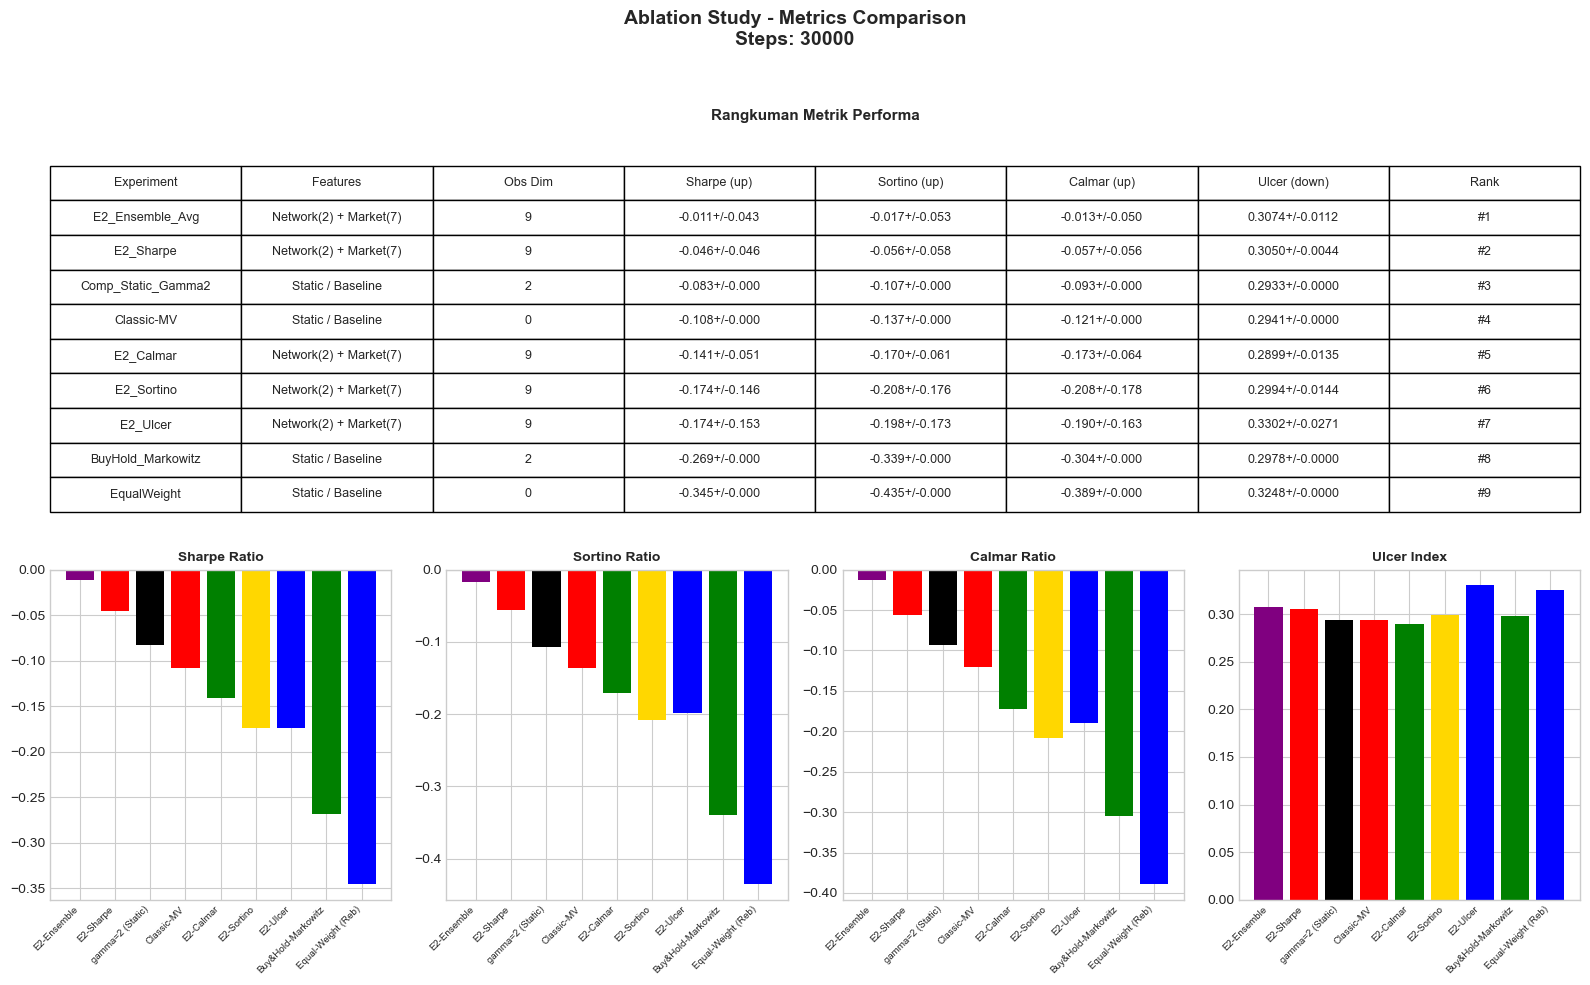

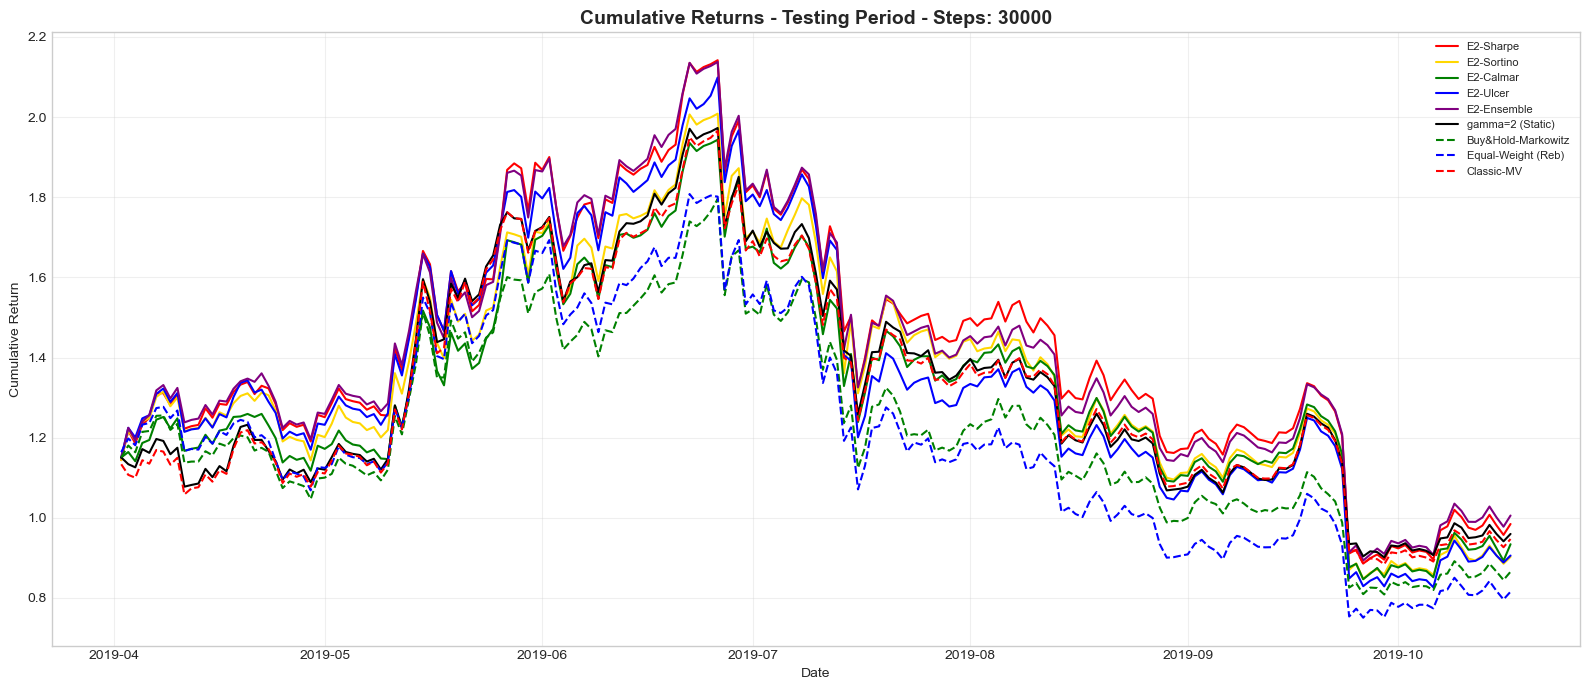

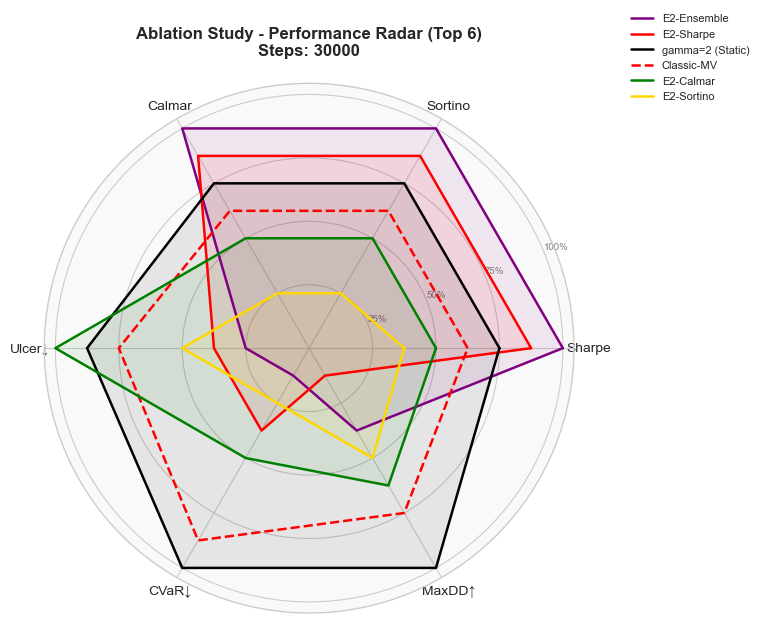

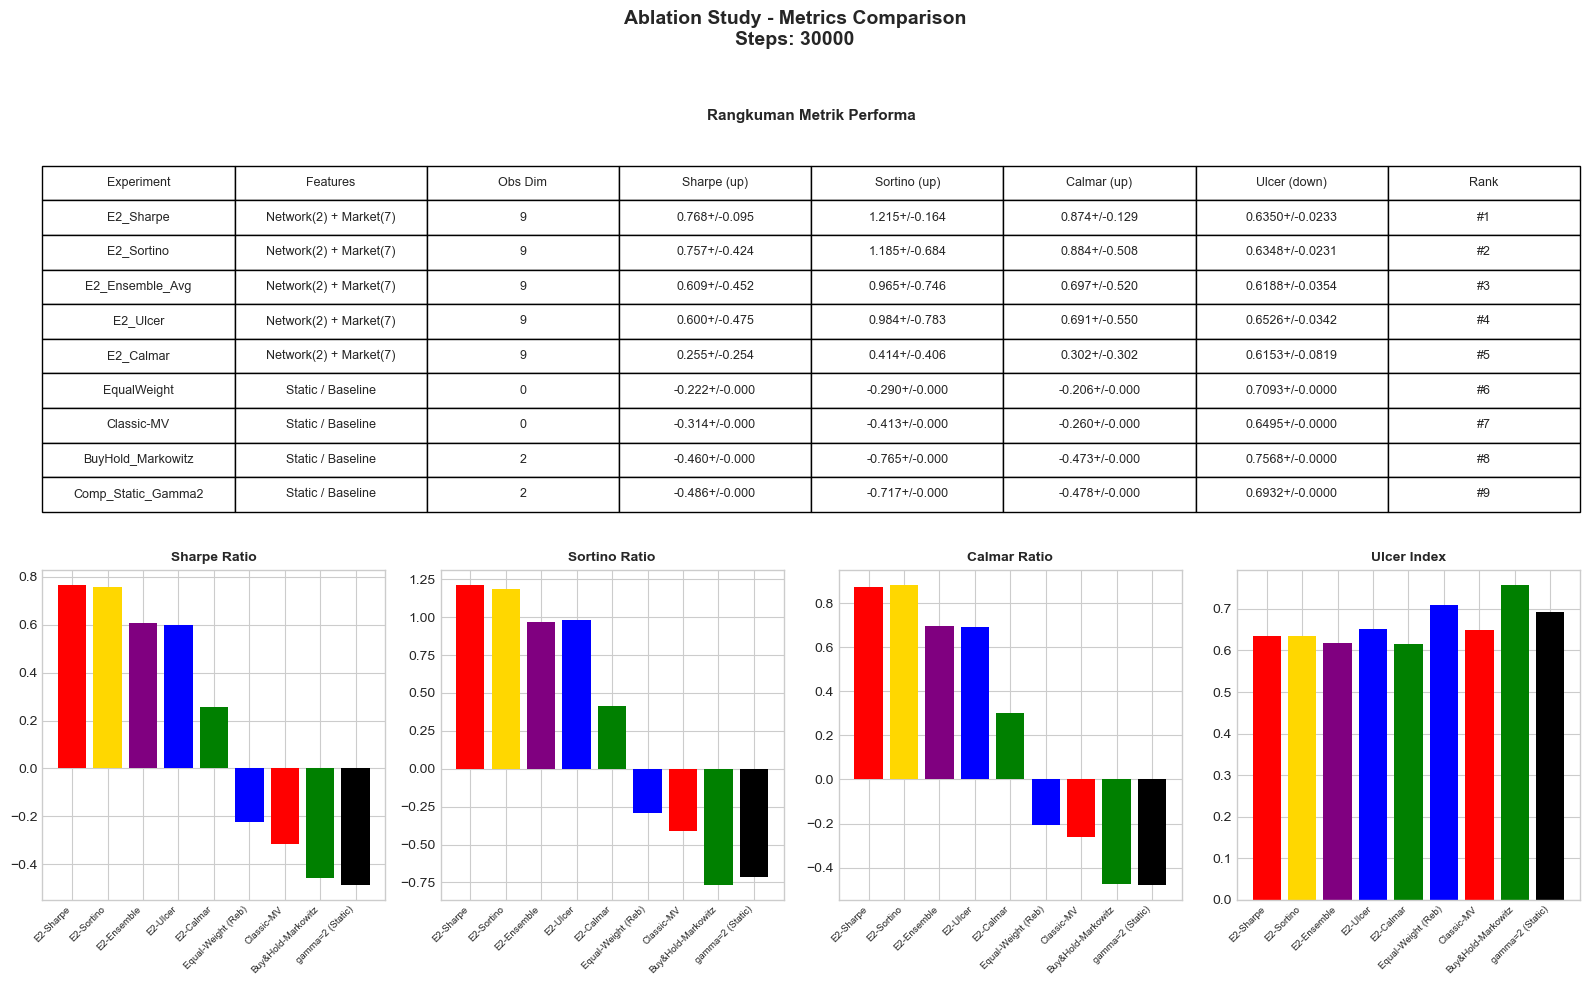

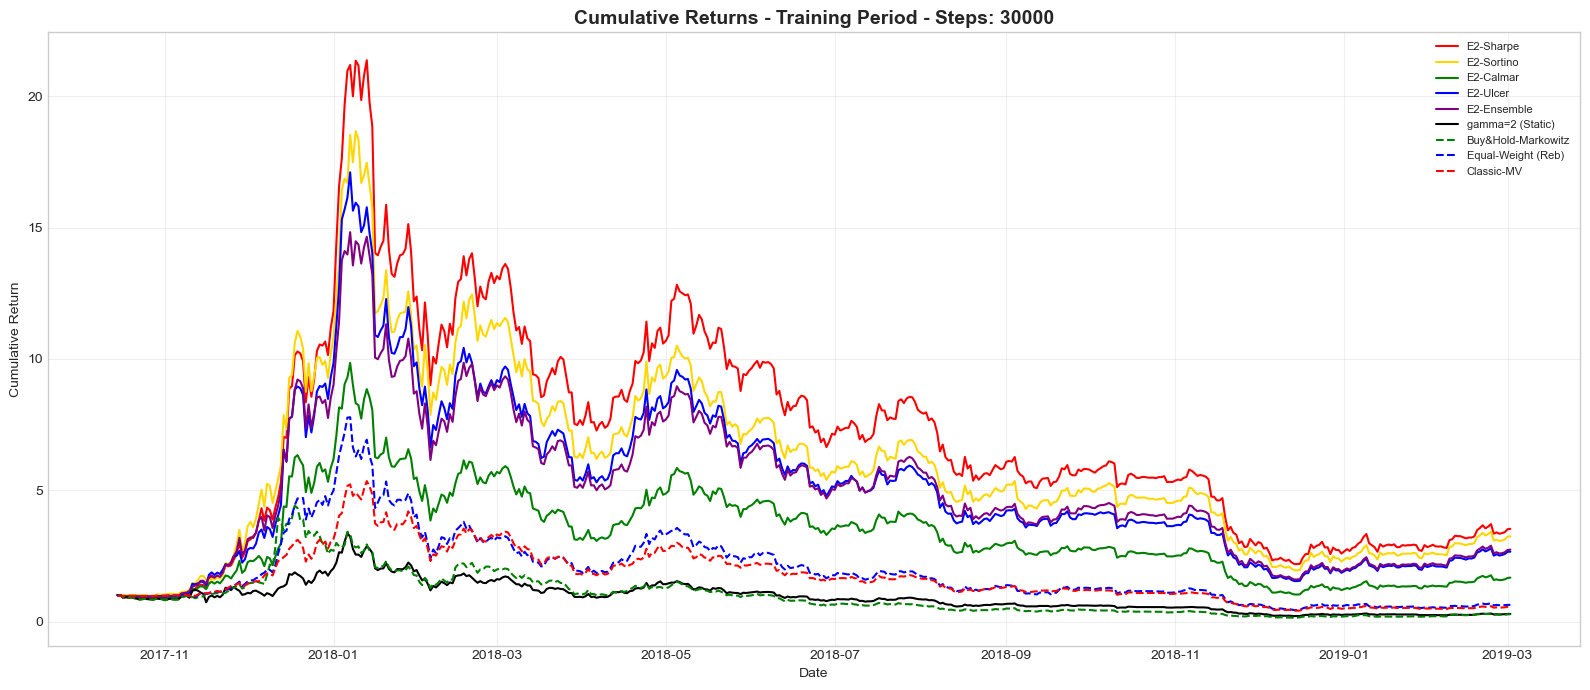

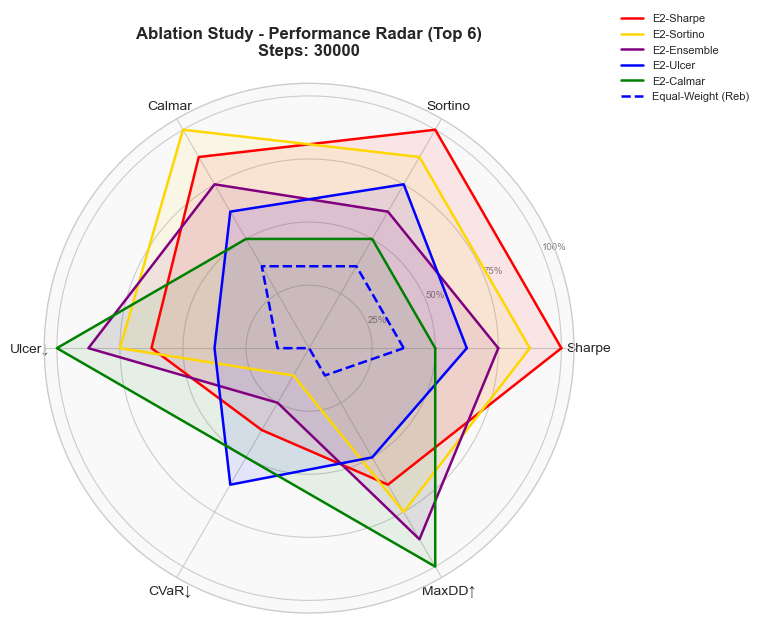


=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===
  E2_Sharpe             : p = 0.7465 
  E2_Sortino            : p = 0.1767 
  E2_Calmar             : p = 0.4408 
  E2_Ulcer              : p = 0.4437 
  E2_Ensemble_Avg       : p = 0.5717 
  Comp_Static_Gamma2    : p = 0.2601 
  BuyHold_Markowitz     : p = 0.5147 
  EqualWeight           : p = 0.2532 
  (* = signifikan pada alpha=0.05)

=== Generating SHAP Analysis ===
Generating SHAP analysis for E2_Sharpe...


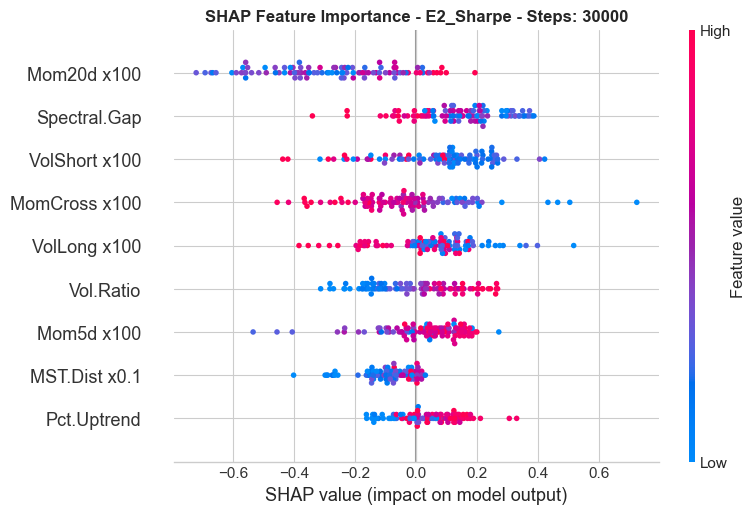

Generating SHAP analysis for E2_Sortino...


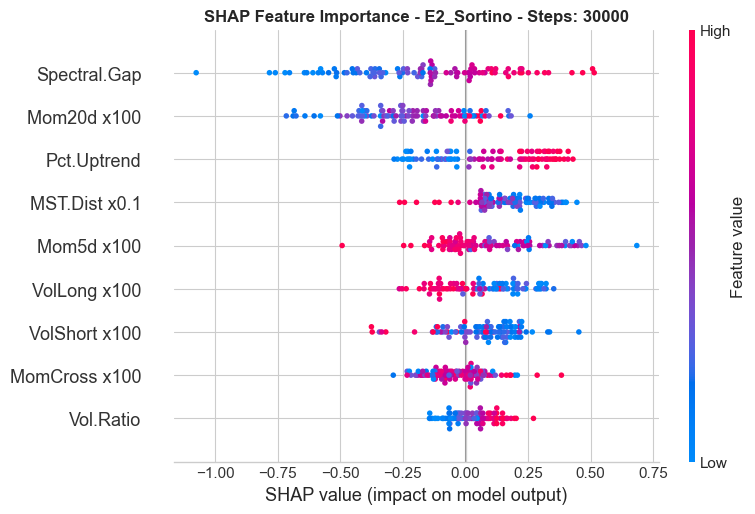

Generating SHAP analysis for E2_Calmar...


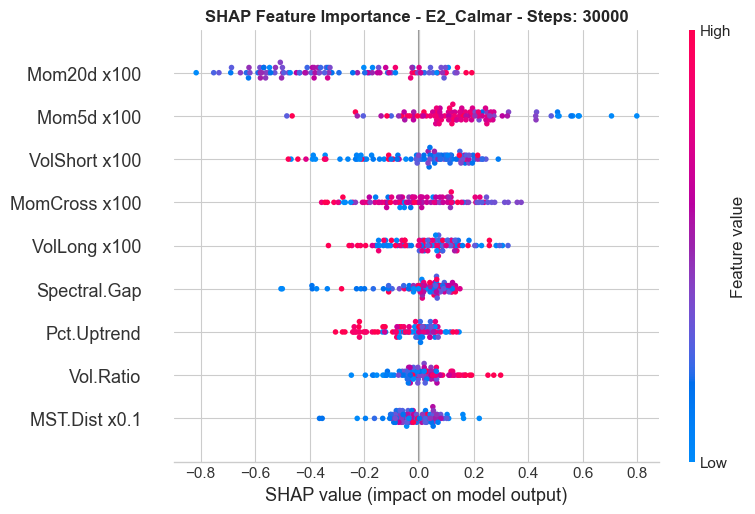

Generating SHAP analysis for E2_Ulcer...


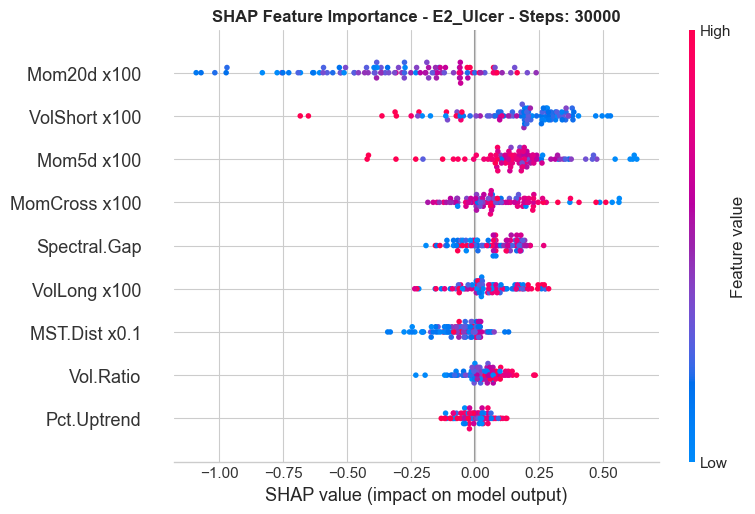

Generating SHAP analysis for E2_Ensemble_Avg...


ExactExplainer explainer: 99it [00:13,  1.81it/s]                        


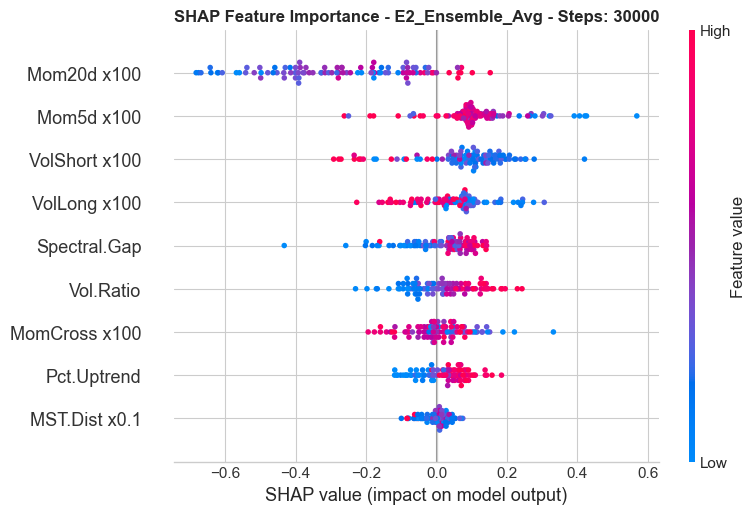


Analisis selesai.


In [12]:
print('\n=== Generating Final Dashboards ===')
generate_dashboard(results_test,  'Ablation Study', 'Testing',  'testing.png')
generate_dashboard(results_train, 'Ablation Study', 'Training', 'training.png')

# FIX: run_wilcoxon_tests sekarang benar-benar dipanggil + hasil ditampilkan
print('\n=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===')
pvals = run_wilcoxon_tests(results_test, baseline_id='Classic-MV')
for exp_id, p in pvals.items():
    sig = '*' if (not np.isnan(p) and p < STAT_ALPHA) else ''
    pstr = f'{p:.4f}' if not np.isnan(p) else 'NaN'
    print(f'  {exp_id:<22}: p = {pstr} {sig}')
print(f'  (* = signifikan pada alpha={STAT_ALPHA})')

print('\n=== Generating SHAP Analysis ===')
seed0 = SEEDS[0]
for exp_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg']:
    config = ABLATION_CONFIGS.get(exp_id, {})
    if exp_id == 'E2_Ensemble_Avg':
        m_paths = [trained_models.get((m, seed0))
                   for m in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']]
    else:
        m_paths = trained_models.get((exp_id, seed0))
    env_shap = AblationPortfolioEnv(ret_test, config, split='test')
    plot_shap_analysis(m_paths, env_shap, config, exp_id)

print('\nAnalisis selesai.')



## 13. Enhanced Analysis — Rolling Window, Bootstrap CI, Regime, Turnover, Extra Baselines

Penambahan eksperimen lanjutan (tanpa menghapus kode apapun):
- **13A** Rolling Sharpe/Sortino/CVaR (60-hari) tiap strategi
- **13B** Bootstrap Confidence Intervals (N=2000) untuk semua metrik
- **13C** Market Regime Detection (HMM-proxy via volatility clustering)
- **13D** Portfolio Turnover & Transaction Cost Analysis (0 / 10 / 30 bps)
- **13E** Additional Baselines: Equal Weight & Inverse Volatility
- **13F** Strategy Return Correlation Heatmap
- **13G** Underwater (Drawdown) Plot yang lebih detail


In [13]:
# ═══════════════════════════════════════════════════════════════════════
# 13E. Additional Baselines: Equal Weight & Inverse Volatility
# ═══════════════════════════════════════════════════════════════════════

def compute_equal_weight(n_assets):
    """Equal weight baseline — paling sederhana."""
    return np.ones(n_assets) / n_assets


def compute_inverse_vol_weights(returns_window, eps=1e-8):
    """
    Inverse Volatility weighting: w_i ∝ 1 / σ_i
    Memberikan bobot lebih tinggi ke aset yang lebih stabil.
    """
    vols = returns_window.std().values + eps
    raw  = 1.0 / vols
    return raw / raw.sum()


# Tambahkan ke ABLATION_COLORS & DISPLAY_NAMES agar konsisten
ABLATION_COLORS['EqWeight']   = '#4CAF50'
ABLATION_COLORS['InvVol']     = '#E91E63'
DISPLAY_NAMES['EqWeight']     = 'Equal Weight'
DISPLAY_NAMES['InvVol']       = 'Inv. Volatility'

# Hitung returns untuk kedua baseline baru
extra_baselines = ['EqWeight', 'InvVol']

for bl_id in extra_baselines:
    results_test[bl_id]  = pd.DataFrame()
    results_train[bl_id] = pd.DataFrame()
    for seed in SEEDS:
        # --- Testing ---
        rets_test_bl = []
        for i in range(SET_WINDOW, len(ret_test)):
            w_bl = (compute_equal_weight(len(assets)) if bl_id == 'EqWeight'
                    else compute_inverse_vol_weights(ret_test.iloc[i-SET_WINDOW:i]))
            rets_test_bl.append(np.dot(w_bl, ret_test.iloc[i].values))
        results_test[bl_id][seed] = pd.Series(
            rets_test_bl, index=ret_test.index[SET_WINDOW:])

        # --- Training (evaluation) ---
        rets_train_bl = []
        for i in range(SET_WINDOW, len(ret_train)):
            w_bl = (compute_equal_weight(len(assets)) if bl_id == 'EqWeight'
                    else compute_inverse_vol_weights(ret_train.iloc[i-SET_WINDOW:i]))
            rets_train_bl.append(np.dot(w_bl, ret_train.iloc[i].values))
        results_train[bl_id][seed] = pd.Series(
            rets_train_bl, index=ret_train.index[SET_WINDOW:])

print('Additional baselines computed: EqWeight, InvVol')

# Ringkasan metrik tambahan
print('\n=== Metrics: Additional Baselines (Test) ===')
for bl_id in extra_baselines:
    m = calculate_all_metrics(results_test[bl_id].mean(axis=1))
    print(f"  {bl_id:<12}: Sharpe={m['Sharpe Ratio']:.3f}, "          f"Sortino={m['Sortino Ratio']:.3f}, "          f"CVaR={m['CVaR (95%)']:.4f}, "          f"MaxDD={m['Max Drawdown']:.3f}")



Additional baselines computed: EqWeight, InvVol

=== Metrics: Additional Baselines (Test) ===
  EqWeight    : Sharpe=-0.345, Sortino=-0.435, CVaR=0.1085, MaxDD=-0.585
  InvVol      : Sharpe=-0.314, Sortino=-0.393, CVaR=0.1073, MaxDD=-0.576


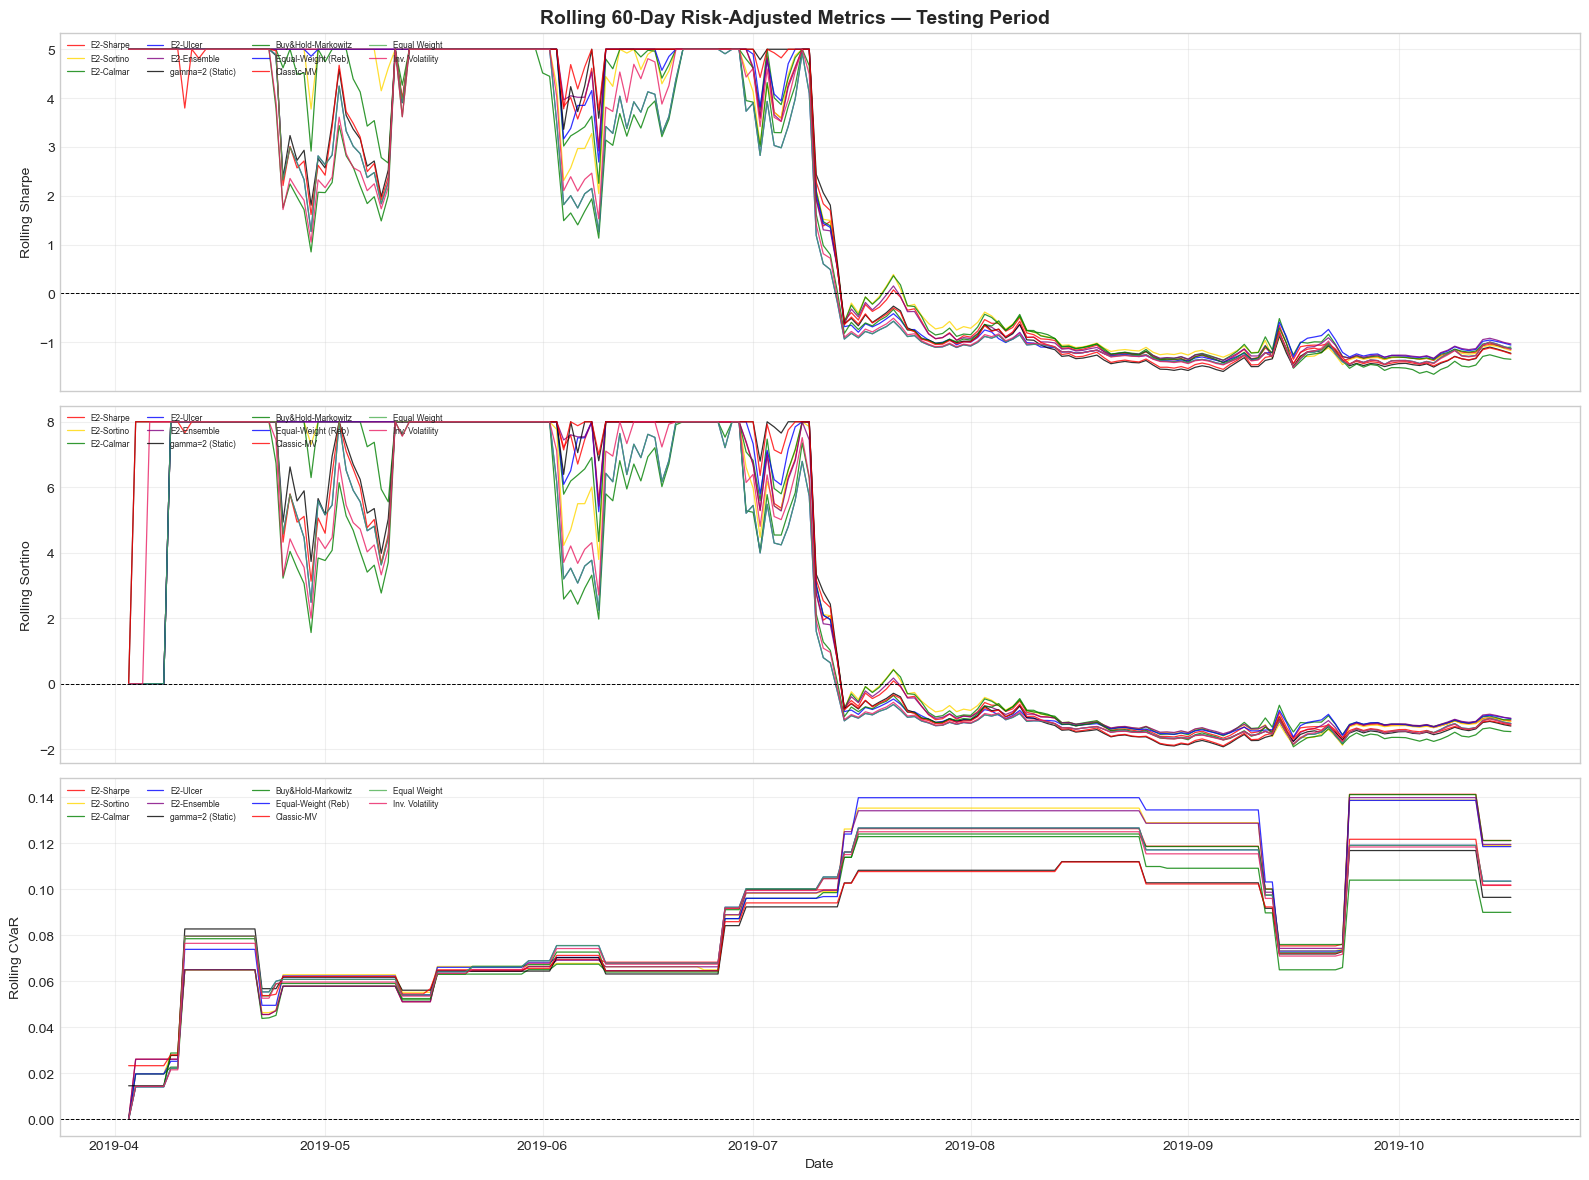

13A Rolling Window Analysis selesai.


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# 13A. Rolling Window Analysis (60-hari)
# ═══════════════════════════════════════════════════════════════════════

ROLLING_WIN = 60   # hari kalender

def compute_rolling_metrics(ret_series, window=ROLLING_WIN):
    """
    Hitung rolling Sharpe, Sortino, dan CVaR.
    Return DataFrame bertanggal sama dengan ret_series.
    """
    arr = np.array(ret_series)
    idx = ret_series.index
    n   = len(arr)
    sharpe_r, sortino_r, cvar_r = [], [], []
    for t in range(n):
        sl = arr[max(0, t - window + 1): t + 1]
        sharpe_r.append(calculate_sharpe_ratio(sl)  if len(sl) > 1 else np.nan)
        sortino_r.append(calculate_sortino_ratio(sl) if len(sl) > 1 else np.nan)
        cvar_r.append(calculate_cvar(sl)             if len(sl) > 1 else np.nan)
    return pd.DataFrame({'Rolling Sharpe': sharpe_r,
                         'Rolling Sortino': sortino_r,
                         'Rolling CVaR'  : cvar_r}, index=idx)


all_strategy_ids = list(ABLATION_CONFIGS.keys()) + ['Classic-MV', 'EqWeight', 'InvVol']
rolling_results  = {}
for exp_id in all_strategy_ids:
    avg_ret = results_test[exp_id].mean(axis=1)
    rolling_results[exp_id] = compute_rolling_metrics(avg_ret, ROLLING_WIN)

# ── Plot Rolling Sharpe ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True, facecolor='white')
fig.suptitle(f'Rolling {ROLLING_WIN}-Day Risk-Adjusted Metrics — Testing Period',
             fontsize=14, fontweight='bold')

for metric, ax, ylim_hint in zip(
        ['Rolling Sharpe', 'Rolling Sortino', 'Rolling CVaR'],
        axes,
        [(-5, 5), (-8, 8), (0, 0.15)]):
    for exp_id in all_strategy_ids:
        series = rolling_results[exp_id][metric].clip(*ylim_hint)
        ax.plot(series, label=get_display_name(exp_id),
                color=ABLATION_COLORS.get(exp_id, '#777777'), alpha=0.8, linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_ylabel(metric, fontsize=10)
    ax.legend(fontsize=6, ncol=4, loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13A_rolling_metrics.png'), dpi=200)
plt.show()
plt.close()
print('13A Rolling Window Analysis selesai.')





=== Bootstrap 95% Confidence Intervals (Test Period) ===


,Strategy,Sharpe Mean,Sharpe 95% CI,Sortino Mean,Sortino 95% CI,Calmar Mean,Calmar 95% CI,CVaR Mean,CVaR 95% CI
0,E2-Ensemble,0.620265,"[-1.087, 5.694]",0.931349,"[-1.236, 8.349]",1.598783,"[-1.071, 12.940]",0.109275,"[0.073, 0.153]"
1,E2-Sharpe,0.549281,"[-1.100, 5.147]",0.858383,"[-1.285, 7.929]",1.460054,"[-1.074, 12.433]",0.107026,"[0.073, 0.150]"
2,E2-Calmar,0.403877,"[-1.128, 4.723]",0.645171,"[-1.299, 6.956]",1.171797,"[-1.082, 10.823]",0.106139,"[0.072, 0.149]"
3,E2-Ulcer,0.357933,"[-1.124, 4.907]",0.601001,"[-1.306, 7.258]",1.074964,"[-1.084, 10.585]",0.110162,"[0.073, 0.155]"
4,gamma=2 (Static),0.352662,"[-1.185, 4.372]",0.584156,"[-1.451, 6.661]",1.078810,"[-1.097, 10.197]",0.094389,"[0.068, 0.125]"
5,E2-Sortino,0.351570,"[-1.130, 4.589]",0.583722,"[-1.332, 6.775]",1.058737,"[-1.082, 10.122]",0.108854,"[0.073, 0.153]"
6,Classic-MV,0.332607,"[-1.185, 4.206]",0.549273,"[-1.437, 6.224]",1.035887,"[-1.094, 9.856]",0.095843,"[0.069, 0.128]"
7,Buy&Hold-Markowitz,0.121316,"[-1.236, 3.766]",0.241907,"[-1.510, 5.127]",0.662395,"[-1.104, 8.336]",0.098210,"[0.071, 0.127]"
8,Inv. Volatility,0.086451,"[-1.208, 3.648]",0.200660,"[-1.467, 5.160]",0.598530,"[-1.101, 8.565]",0.103396,"[0.074, 0.135]"
9,Equal-Weight (Reb),0.047315,"[-1.206, 3.507]",0.150203,"[-1.481, 5.183]",0.532799,"[-1.099, 8.320]",0.104626,"[0.075, 0.136]"


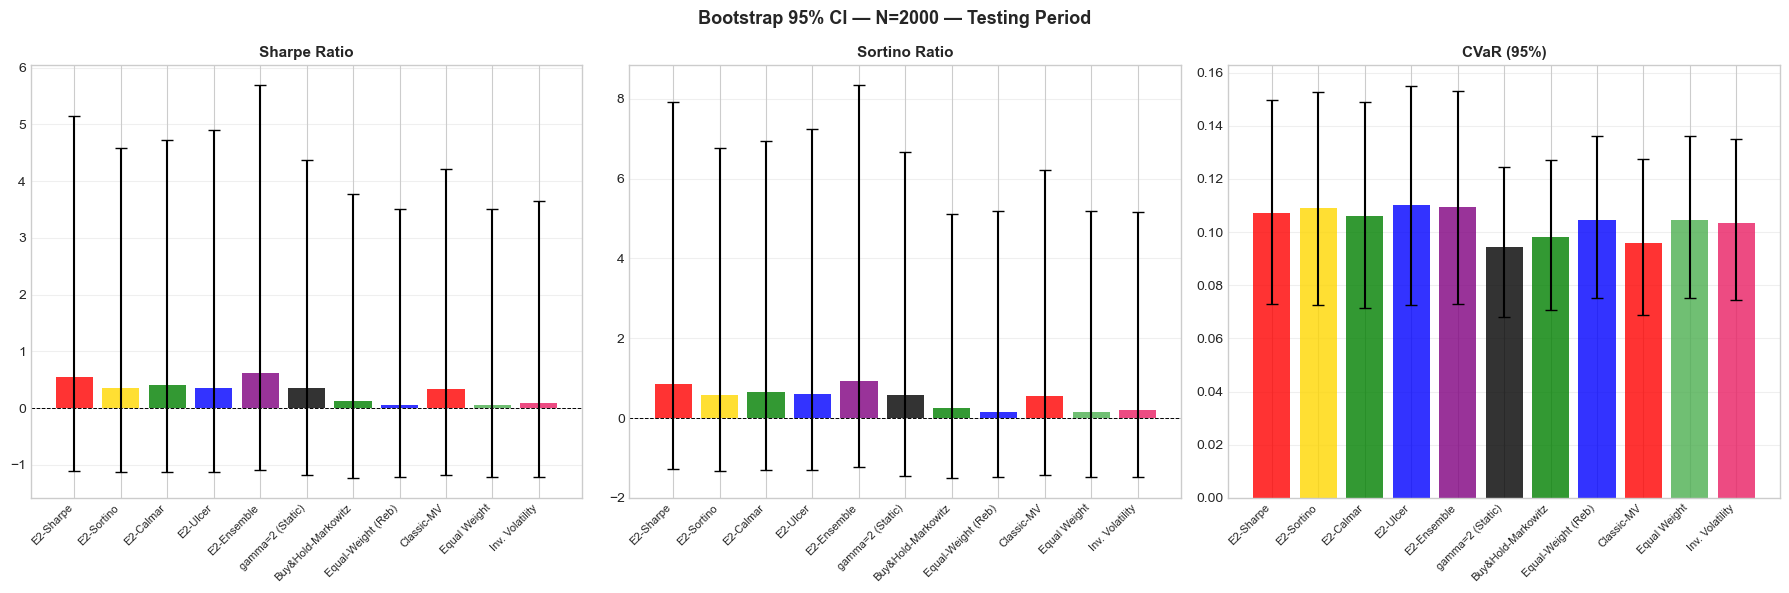

13B Bootstrap CI selesai.


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# 13B. Bootstrap Confidence Intervals (N=2000, 95% CI)
# ═══════════════════════════════════════════════════════════════════════

N_BOOT   = 2000
CI_ALPHA = 0.05   # 95% CI

def bootstrap_ci(ret_series, metric_fn, n_boot=N_BOOT, alpha=CI_ALPHA, seed=0):
    """
    Parametric bootstrap: re-sample dengan replacement dari distribusi empiris.
    Mengembalikan (mean, lower_ci, upper_ci).
    """
    rng  = np.random.default_rng(seed)
    arr  = np.array(ret_series)
    n    = len(arr)
    stats_boot = [metric_fn(rng.choice(arr, size=n, replace=True)) for _ in range(n_boot)]
    stats_boot = np.array(stats_boot)
    lo = np.percentile(stats_boot, 100 * alpha / 2)
    hi = np.percentile(stats_boot, 100 * (1 - alpha / 2))
    return float(stats_boot.mean()), float(lo), float(hi)


ci_rows = []
for exp_id in all_strategy_ids:
    avg_ret = results_test[exp_id].mean(axis=1)
    sharpe_m, sharpe_lo, sharpe_hi   = bootstrap_ci(avg_ret, calculate_sharpe_ratio)
    sortino_m, sortino_lo, sortino_hi = bootstrap_ci(avg_ret, calculate_sortino_ratio)
    calmar_m, calmar_lo, calmar_hi   = bootstrap_ci(avg_ret, calculate_calmar_ratio)
    cvar_m, cvar_lo, cvar_hi         = bootstrap_ci(avg_ret, calculate_cvar)
    ci_rows.append({
        'Strategy'      : get_display_name(exp_id),
        'Sharpe Mean'   : sharpe_m,
        'Sharpe 95% CI' : f'[{sharpe_lo:.3f}, {sharpe_hi:.3f}]',
        'Sortino Mean'  : sortino_m,
        'Sortino 95% CI': f'[{sortino_lo:.3f}, {sortino_hi:.3f}]',
        'Calmar Mean'   : calmar_m,
        'Calmar 95% CI' : f'[{calmar_lo:.3f}, {calmar_hi:.3f}]',
        'CVaR Mean'     : cvar_m,
        'CVaR 95% CI'   : f'[{cvar_lo:.3f}, {cvar_hi:.3f}]',
    })

df_ci = pd.DataFrame(ci_rows).sort_values('Sharpe Mean', ascending=False).reset_index(drop=True)
print('\n=== Bootstrap 95% Confidence Intervals (Test Period) ===')
display(df_ci[['Strategy','Sharpe Mean','Sharpe 95% CI',
               'Sortino Mean','Sortino 95% CI',
               'Calmar Mean','Calmar 95% CI',
               'CVaR Mean','CVaR 95% CI']])

# ── Plot Bootstrap CI as Error Bars ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
fig.suptitle(f'Bootstrap 95% CI — N={N_BOOT} — Testing Period',
             fontsize=13, fontweight='bold')

for ax, metric_fn, col_m, col_ci, label in zip(
        axes,
        [calculate_sharpe_ratio, calculate_sortino_ratio, calculate_cvar],
        ['Sharpe Mean', 'Sortino Mean', 'CVaR Mean'],
        ['Sharpe 95% CI', 'Sortino 95% CI', 'CVaR 95% CI'],
        ['Sharpe Ratio', 'Sortino Ratio', 'CVaR (95%)']):
    means, los, his, names, cols = [], [], [], [], []
    for exp_id in all_strategy_ids:
        avg_ret = results_test[exp_id].mean(axis=1)
        m, lo, hi = bootstrap_ci(avg_ret, metric_fn)
        means.append(m); los.append(lo); his.append(hi)
        names.append(get_display_name(exp_id))
        cols.append(ABLATION_COLORS.get(exp_id, '#777777'))
    x = range(len(names))
    ax.bar(x, means, color=cols, alpha=0.8, zorder=2)
    ax.errorbar(x, means,
                yerr=[np.array(means)-np.array(los), np.array(his)-np.array(means)],
                fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13B_bootstrap_ci.png'), dpi=200)
plt.show()
plt.close()
print('13B Bootstrap CI selesai.')



Regime threshold (median vol): 0.045691
High Vol (Bear)    124
Low Vol (Bull)     105

=== Performance by Market Regime (Test Period) ===


,Strategy,Regime,N days,Sharpe,Sortino,CVaR,Max DD,Total Ret
0,E2-Sharpe,Low Vol (Bull),94,0.563370,0.980366,0.065769,-0.248912,0.104767
1,E2-Sharpe,High Vol (Bear),105,-0.308618,-0.337687,0.131698,-0.485856,-0.108837
2,E2-Sortino,Low Vol (Bull),94,0.310300,0.530389,0.066489,-0.251739,0.058936
3,E2-Sortino,High Vol (Bear),105,-0.399414,-0.435703,0.136390,-0.477330,-0.147645
4,E2-Calmar,Low Vol (Bull),94,0.302721,0.514688,0.065683,-0.239327,0.057650
5,E2-Calmar,High Vol (Bear),105,-0.333418,-0.356095,0.131105,-0.468608,-0.116868
6,E2-Ulcer,Low Vol (Bull),94,0.651198,1.170300,0.064181,-0.238330,0.117808
7,E2-Ulcer,High Vol (Bear),105,-0.500038,-0.536465,0.138131,-0.525402,-0.189649
8,E2-Ensemble,Low Vol (Bull),94,0.653708,1.139896,0.064655,-0.230300,0.117840
9,E2-Ensemble,High Vol (Bear),105,-0.281624,-0.301384,0.136670,-0.497625,-0.100342


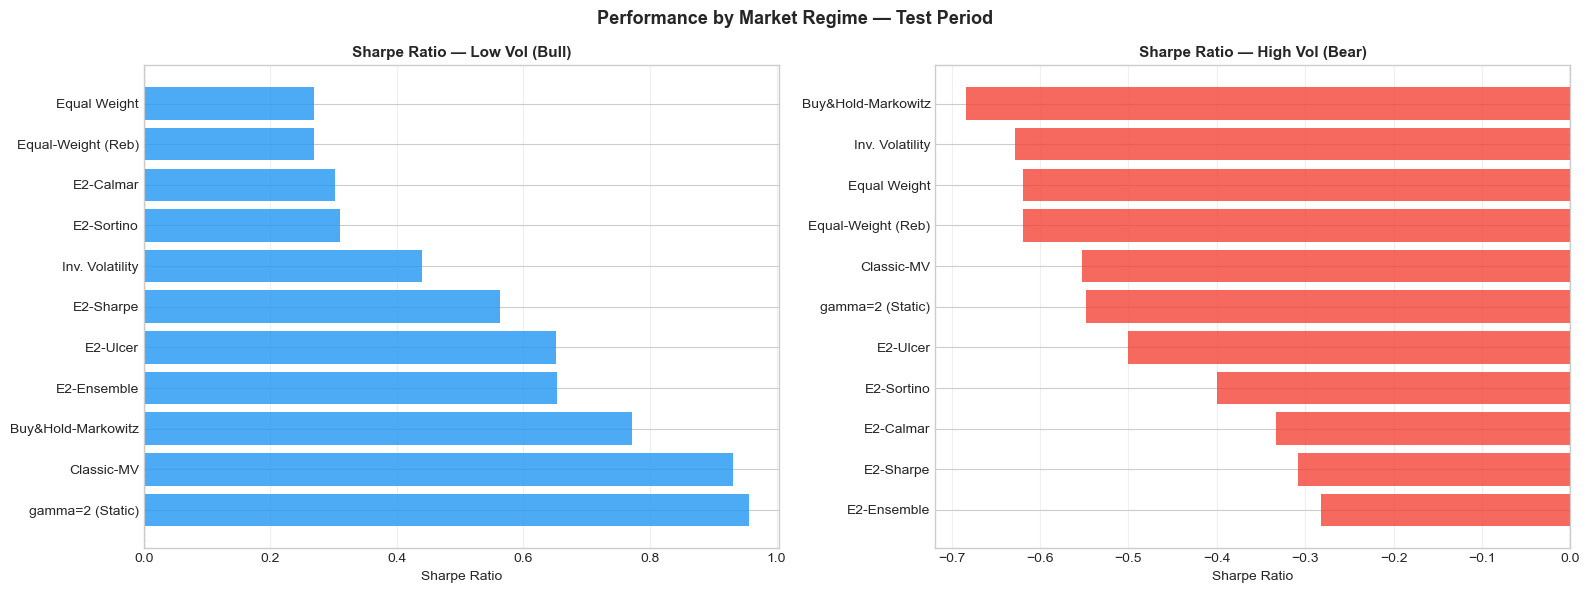

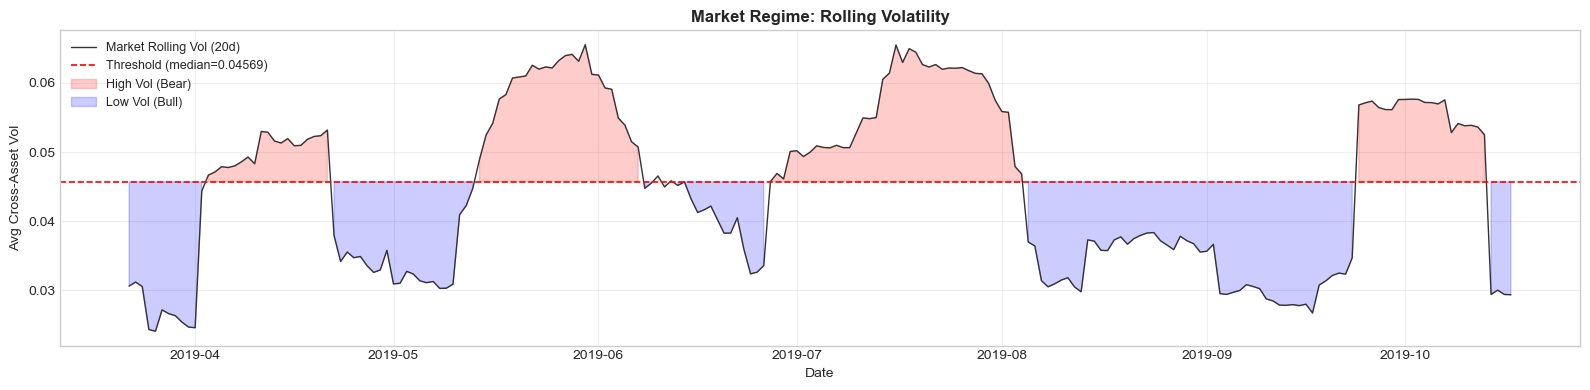

13C Regime Detection selesai.


In [16]:
# ═══════════════════════════════════════════════════════════════════════
# 13C. Market Regime Detection (Volatility-Based Proxy)
# ═══════════════════════════════════════════════════════════════════════
# Menggunakan rolling volatility market-wide untuk mendefinisikan:
#   Low Vol  → Bull / Calm regime
#   High Vol → Bear / Crisis regime
# Threshold: median rolling volatility pada test period.

def detect_regimes(ret_df, window=20):
    """
    Hitung market-wide rolling volatility (rata-rata cross-asset).
    Klasifikasikan setiap tanggal ke 'Low Vol' atau 'High Vol'.
    """
    roll_vol = ret_df.rolling(window).std().mean(axis=1)
    median   = roll_vol.median()
    regimes  = np.where(roll_vol <= median, 'Low Vol (Bull)', 'High Vol (Bear)')
    return pd.Series(regimes, index=ret_df.index), roll_vol, median

regimes_series, roll_vol_market, vol_median = detect_regimes(ret_test, window=20)

print(f'Regime threshold (median vol): {vol_median:.6f}')
print(regimes_series.value_counts().to_string())

# Metrik per regime per strategi
regime_metrics = []
for exp_id in all_strategy_ids:
    avg_ret = results_test[exp_id].mean(axis=1)
    for regime_name in ['Low Vol (Bull)', 'High Vol (Bear)']:
        mask = regimes_series.loc[avg_ret.index] == regime_name
        sub  = avg_ret[mask]
        if len(sub) < 5:
            continue
        m = calculate_all_metrics(sub)
        regime_metrics.append({
            'Strategy'  : get_display_name(exp_id),
            'Regime'    : regime_name,
            'N days'    : len(sub),
            'Sharpe'    : m['Sharpe Ratio'],
            'Sortino'   : m['Sortino Ratio'],
            'CVaR'      : m['CVaR (95%)'],
            'Max DD'    : m['Max Drawdown'],
            'Total Ret' : m['Total Return'],
        })

df_regime = pd.DataFrame(regime_metrics)
print('\n=== Performance by Market Regime (Test Period) ===')
display(df_regime)

# ── Plot: Sharpe per regime ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
fig.suptitle('Performance by Market Regime — Test Period', fontsize=13, fontweight='bold')

for ax, regime_name, color in zip(
        [ax1, ax2],
        ['Low Vol (Bull)', 'High Vol (Bear)'],
        ['#2196F3', '#F44336']):
    sub = df_regime[df_regime['Regime'] == regime_name].sort_values('Sharpe', ascending=False)
    ax.barh(sub['Strategy'], sub['Sharpe'], color=color, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Sharpe Ratio — {regime_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sharpe Ratio')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13C_regime_analysis.png'), dpi=200)
plt.show()
plt.close()

# ── Plot: Rolling Volatility dengan regime shading ────────────────────────
fig, ax = plt.subplots(figsize=(16, 4), facecolor='white')
ax.plot(roll_vol_market, color='#333333', linewidth=1, label='Market Rolling Vol (20d)')
ax.axhline(vol_median, color='red', linestyle='--', linewidth=1.2, label=f'Threshold (median={vol_median:.5f})')
ax.fill_between(roll_vol_market.index, roll_vol_market, vol_median,
                where=(roll_vol_market > vol_median),
                alpha=0.2, color='red', label='High Vol (Bear)')
ax.fill_between(roll_vol_market.index, roll_vol_market, vol_median,
                where=(roll_vol_market <= vol_median),
                alpha=0.2, color='blue', label='Low Vol (Bull)')
ax.set_title('Market Regime: Rolling Volatility', fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Cross-Asset Vol')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13C_regime_vol.png'), dpi=200)
plt.show()
plt.close()
print('13C Regime Detection selesai.')


Computing weights series for turnover analysis...


Turnover:   0%|          | 0/11 [00:00<?, ?it/s]


=== Turnover & Transaction Cost Sensitivity (Test Period) ===


,Strategy,Avg Turnover/Period,Ann. Turnover (252d),Sharpe (tc=0bps),Sharpe (tc=10bps),Sharpe (tc=30bps),Error
0,E2-Sharpe,0.3167,79.81,-0.029,-0.067,-0.140,NaN
1,E2-Sortino,0.2950,74.34,-0.177,-0.208,-0.267,NaN
2,E2-Calmar,0.3537,89.14,-0.123,-0.162,-0.236,NaN
3,E2-Ulcer,0.3143,79.21,-0.172,-0.218,-0.303,NaN
4,E2-Ensemble,0.3000,75.61,0.011,-0.032,-0.113,NaN
5,gamma=2 (Static),0.0945,23.80,-0.083,-0.093,-0.113,NaN
6,Buy&Hold-Markowitz,NaN,NaN,NaN,NaN,NaN,"('t', 30)"
7,Equal-Weight (Reb),NaN,NaN,NaN,NaN,NaN,"('EqualWeight', 42)"
8,Classic-MV,0.0969,24.42,-0.108,-0.113,-0.122,NaN
9,Equal Weight,0.0000,0.00,-0.345,-0.345,-0.345,NaN


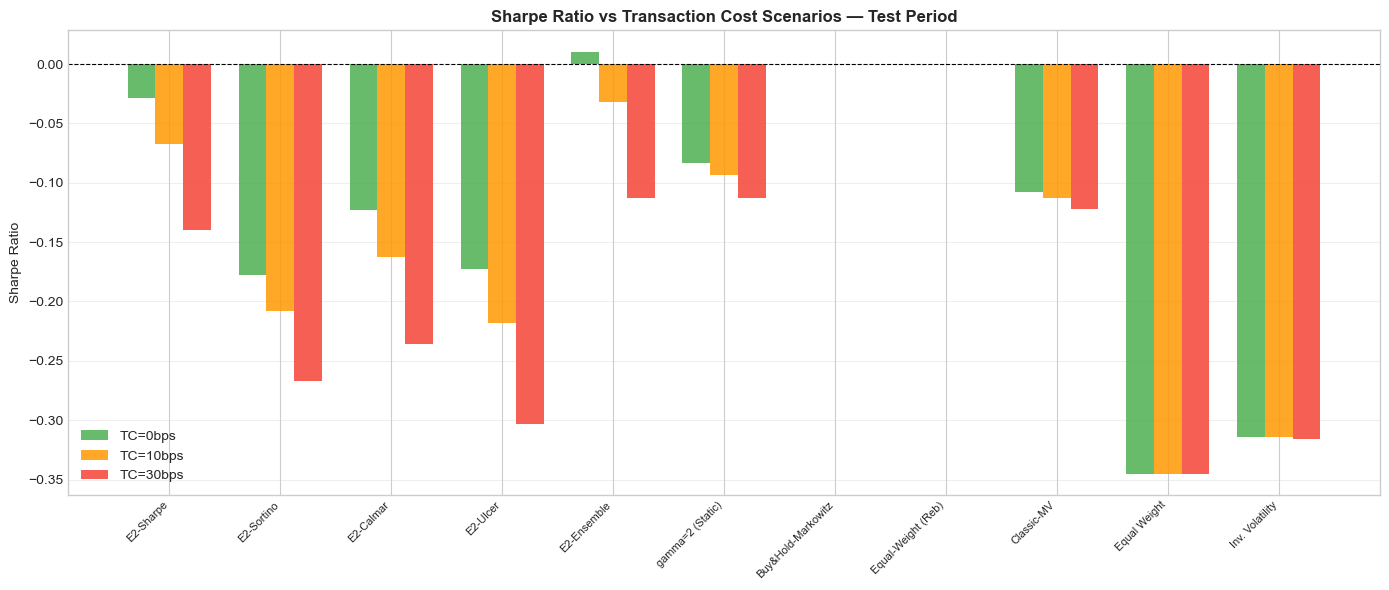

13D Turnover & Transaction Cost Analysis selesai.


In [17]:
# ═══════════════════════════════════════════════════════════════════════
# 13D. Portfolio Turnover & Transaction Cost Analysis
# ═══════════════════════════════════════════════════════════════════════
# Turnover = Σ |w_t - w_{t-1}| / 2  (rata-rata double-count)
# TC scenarios: 0 bps, 10 bps, 30 bps per periode rebalance

TC_BPS_LIST = [0, 10, 30]   # basis points

def compute_weights_series(exp_id, split='test'):
    """Rekonstruksi series bobot portfolio per langkah backtest."""
    data      = ret_test if split == 'test' else ret_train
    cache_key = split
    config    = ABLATION_CONFIGS.get(exp_id, {})
    seed      = SEEDS[0]
    N         = len(assets)

    model           = None
    ensemble_models = []

    if exp_id not in ['Classic-MV', 'EqWeight', 'InvVol'] and not ABLATION_CONFIGS.get(exp_id, {}).get('is_buyhold'):
        if config.get('is_ensemble'):
            for m_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']:
                ensemble_models.append(SAC.load(trained_models[(m_id, seed)]))
        elif config.get('static_gamma') is None:
            model = SAC.load(trained_models[(exp_id, seed)])

    weights_list = []
    for i in range(SET_WINDOW, len(data)):
        c = GLOBAL_CACHE[(cache_key, i)]
        if exp_id == 'Classic-MV':
            w = compute_classic_mv_weights(c['win'])
        elif exp_id == 'EqWeight':
            w = compute_equal_weight(N)
        elif exp_id == 'InvVol':
            w = compute_inverse_vol_weights(c['win'])
        elif ABLATION_CONFIGS.get(exp_id, {}).get('is_buyhold'):
            # Untuk turnover: reconstruct drifted weights s/d titik ini
            c0 = GLOBAL_CACHE[(cache_key[0], SET_WINDOW)]
            w  = fast_centrality_weights(c0['cov_f'], c0['cent_vec'], c0['mu'], gamma=1.0)
            for j in range(SET_WINDOW, i):
                r_vec = data.iloc[j].values
                w = w * (1 + r_vec)
                s = w.sum()
                w = w / s if s > 1e-10 else np.ones(N) / N
        elif config.get('static_gamma') is not None:
            w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
        elif config.get('is_ensemble'):
            obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
            gammas  = [float(em.predict(obs, deterministic=True)[0][0]) for em in ensemble_models]
            w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], np.mean(gammas))
        else:
            obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
            action, _ = model.predict(obs, deterministic=True)
            w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
        weights_list.append(w)

    return np.array(weights_list)


def compute_turnover(weights_arr):
    """Rata-rata one-way turnover per periode."""
    if len(weights_arr) < 2:
        return 0.0
    diffs = np.abs(np.diff(weights_arr, axis=0)).sum(axis=1)
    return float(diffs.mean() / 2)


def apply_transaction_costs(ret_series_vals, weights_arr, tc_bps):
    """Kurangi return dengan biaya transaksi."""
    tc_frac = tc_bps / 10000.0
    rets    = np.array(ret_series_vals)
    n       = min(len(rets), len(weights_arr))
    rets    = rets[:n].copy()
    if n > 1:
        turnovers = np.abs(np.diff(weights_arr[:n], axis=0)).sum(axis=1)
        # Biaya dikurangkan pada hari rebalance (setiap SET_REBALANCE hari)
        for t in range(1, n):
            if (t % SET_REBALANCE) == 0:
                rets[t] -= tc_frac * turnovers[t - 1]
    return rets


# Hitung dan tampilkan
turnover_rows = []
tc_rows       = []

print('Computing weights series for turnover analysis...')
for exp_id in tqdm(all_strategy_ids, desc='Turnover'):
    try:
        w_arr    = compute_weights_series(exp_id, split='test')
        turnover = compute_turnover(w_arr)
        avg_ret_vals = results_test[exp_id].mean(axis=1).values

        row = {'Strategy': get_display_name(exp_id), 'Avg Turnover/Period': f'{turnover:.4f}',
               'Ann. Turnover (252d)': f'{turnover * 252:.2f}'}

        for tc in TC_BPS_LIST:
            ret_tc = apply_transaction_costs(avg_ret_vals, w_arr, tc)
            m_tc   = calculate_all_metrics(ret_tc)
            row[f'Sharpe (tc={tc}bps)'] = f"{m_tc['Sharpe Ratio']:.3f}"
        turnover_rows.append(row)

    except Exception as e:
        turnover_rows.append({'Strategy': get_display_name(exp_id), 'Error': str(e)})

df_turnover = pd.DataFrame(turnover_rows)
print('\n=== Turnover & Transaction Cost Sensitivity (Test Period) ===')
display(df_turnover)

# ── Plot: Sharpe degradation dengan TC ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')
x      = np.arange(len(all_strategy_ids))
width  = 0.25
colors = ['#4CAF50', '#FF9800', '#F44336']

for j, tc in enumerate(TC_BPS_LIST):
    sharpes = []
    for exp_id in all_strategy_ids:
        try:
            w_arr        = compute_weights_series(exp_id, split='test')
            avg_ret_vals = results_test[exp_id].mean(axis=1).values
            ret_tc       = apply_transaction_costs(avg_ret_vals, w_arr, tc)
            sharpes.append(calculate_sharpe_ratio(ret_tc))
        except Exception:
            sharpes.append(np.nan)
    ax.bar(x + j * width, sharpes, width, label=f'TC={tc}bps',
           color=colors[j], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([get_display_name(e) for e in all_strategy_ids],
                   rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Sharpe Ratio vs Transaction Cost Scenarios — Test Period',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13D_transaction_cost.png'), dpi=200)
plt.show()
plt.close()
print('13D Turnover & Transaction Cost Analysis selesai.')



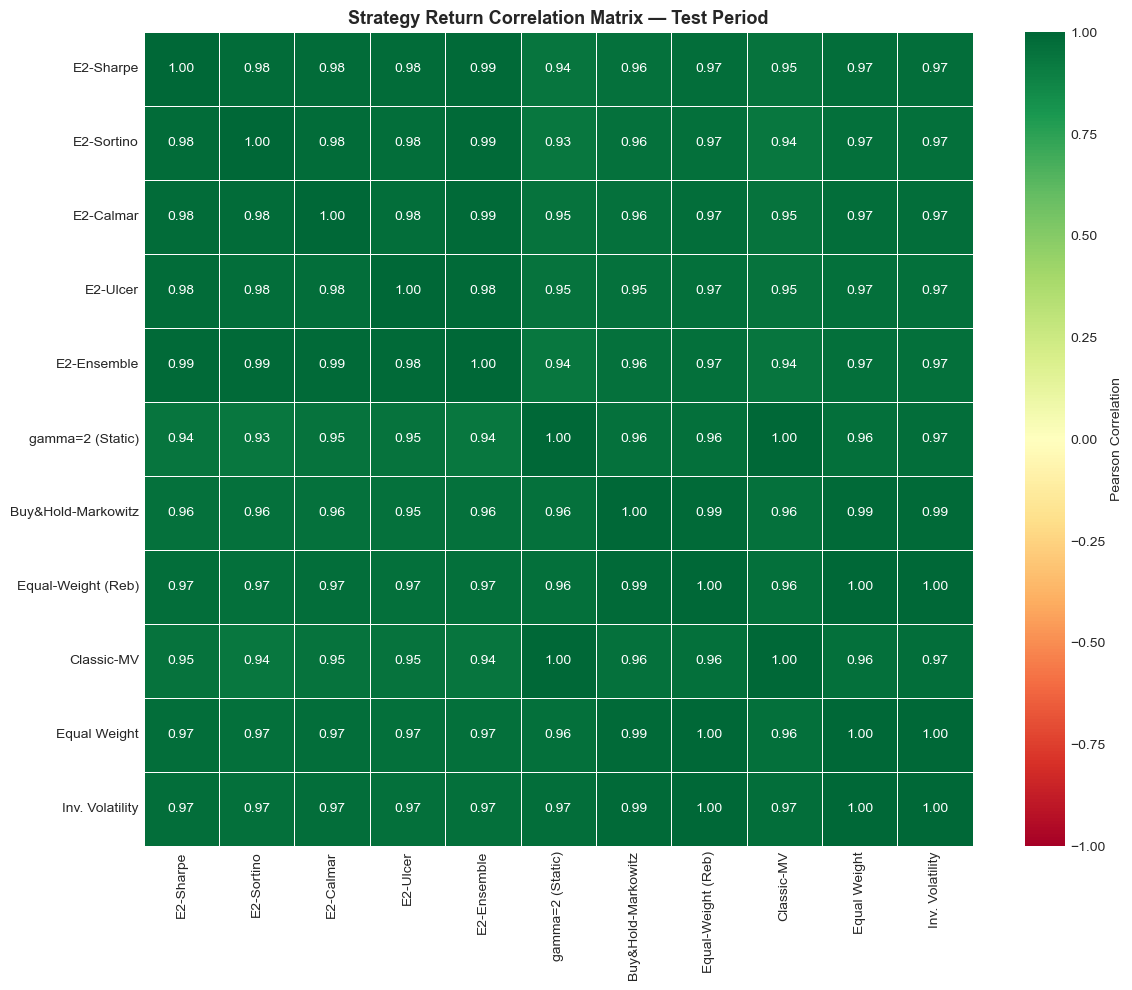

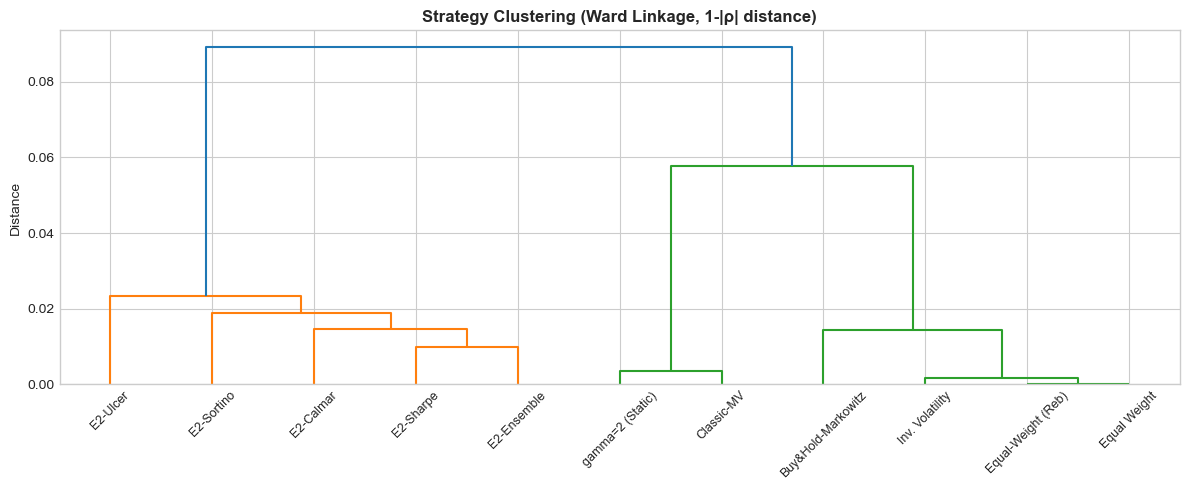

13F Correlation Heatmap & Dendrogram selesai.


In [18]:
# ═══════════════════════════════════════════════════════════════════════
# 13F. Strategy Return Correlation Heatmap
# ═══════════════════════════════════════════════════════════════════════
# Menunjukkan diversifikasi antar strategi — penting untuk ensemble thesis.

ret_matrix = pd.DataFrame({
    get_display_name(exp_id): results_test[exp_id].mean(axis=1)
    for exp_id in all_strategy_ids
})

corr_matrix = ret_matrix.corr()

fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson Correlation'},
)
ax.set_title('Strategy Return Correlation Matrix — Test Period',
             fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13F_correlation_heatmap.png'), dpi=200)
plt.show()
plt.close()

# ── Cluster by correlation ────────────────────────────────────────────────
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

dist_matrix   = 1 - corr_matrix.abs()
np.fill_diagonal(dist_matrix.values, 0)
condensed     = squareform(dist_matrix.values)
linkage_mat   = hierarchy.linkage(condensed, method='ward')

fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')
hierarchy.dendrogram(linkage_mat, labels=corr_matrix.columns.tolist(),
                     ax=ax, leaf_rotation=45, leaf_font_size=9)
ax.set_title('Strategy Clustering (Ward Linkage, 1-|ρ| distance)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13F_strategy_dendrogram.png'), dpi=200)
plt.show()
plt.close()
print('13F Correlation Heatmap & Dendrogram selesai.')


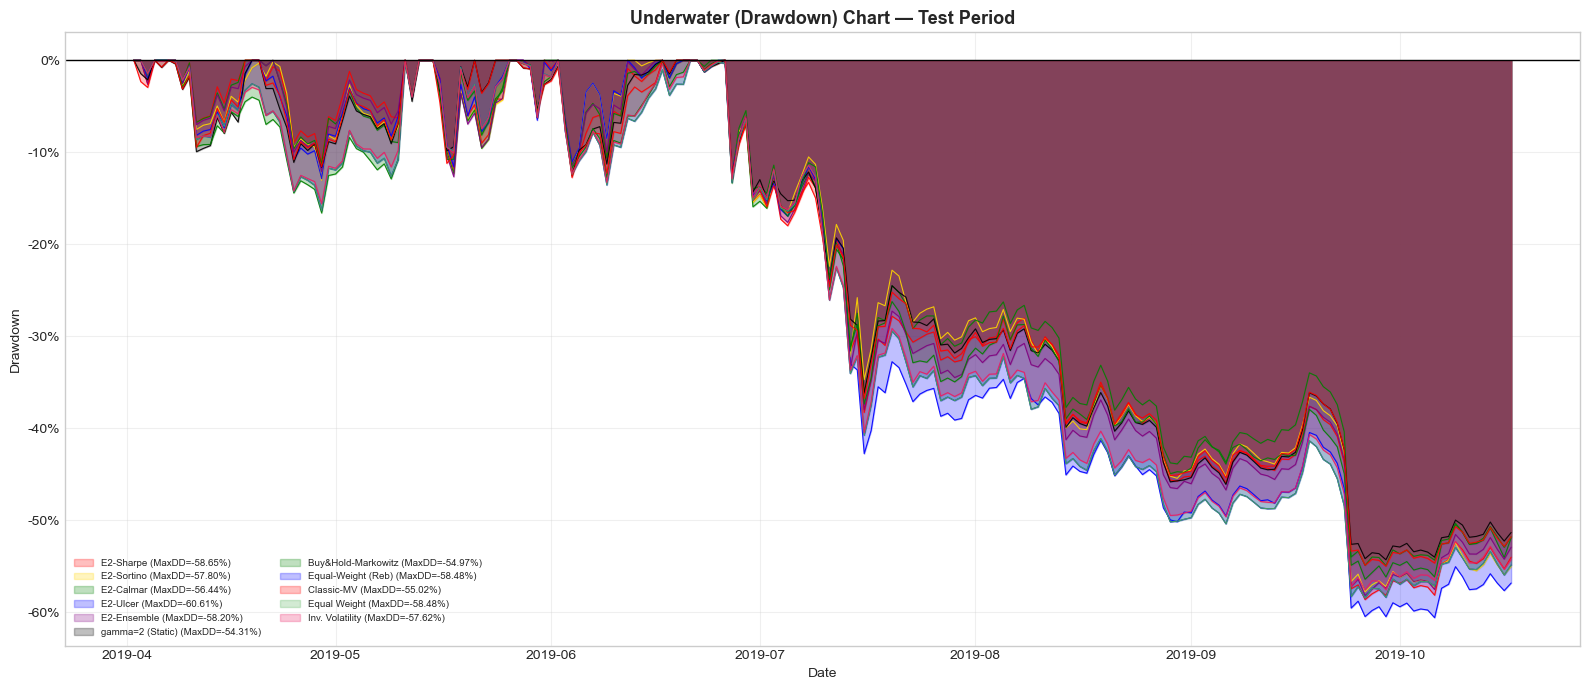


=== Drawdown Statistics (Test Period) ===


,Strategy,Max DD,Avg DD,Avg Recovery,N Severe (>5d)
0,E2-Sharpe,-58.65%,-25.89%,6.3 periods,4
1,E2-Sortino,-57.80%,-25.41%,6.3 periods,3
2,E2-Calmar,-56.44%,-24.90%,6.2 periods,4
3,E2-Ulcer,-60.61%,-28.29%,6.3 periods,4
4,E2-Ensemble,-58.20%,-26.43%,5.6 periods,4
5,gamma=2 (Static),-54.31%,-25.05%,6.6 periods,3
6,Buy&Hold-Markowitz,-54.97%,-25.66%,11.5 periods,3
7,Equal-Weight (Reb),-58.48%,-27.30%,13.6 periods,3
8,Classic-MV,-55.02%,-25.30%,6.5 periods,3
9,Equal Weight,-58.48%,-27.30%,13.6 periods,3


13G Underwater Drawdown Analysis selesai.


In [19]:
# ═══════════════════════════════════════════════════════════════════════
# 13G. Underwater (Drawdown) Plot & Drawdown Statistics
# ═══════════════════════════════════════════════════════════════════════

def compute_full_drawdown_stats(ret_series):
    """
    Hitung statistik drawdown lengkap:
    Max DD, Avg DD, Avg Recovery Period, # DD Periods > 5%.
    """
    arr = np.array(ret_series)
    cum = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cum)
    dd   = (cum - peak) / peak

    max_dd   = dd.min()
    avg_dd   = dd[dd < 0].mean() if (dd < 0).any() else 0.0

    # Recovery periods
    in_dd, recovery_lens = False, []
    cur_len = 0
    for v in dd:
        if v < 0:
            in_dd = True; cur_len += 1
        elif in_dd:
            recovery_lens.append(cur_len); cur_len = 0; in_dd = False

    avg_recovery = float(np.mean(recovery_lens)) if recovery_lens else 0.0
    n_severe     = int(np.sum(np.array(recovery_lens) > 5))

    return {
        'Max DD'        : max_dd,
        'Avg DD'        : avg_dd,
        'Avg Recovery'  : avg_recovery,
        'N Severe (>5d)': n_severe,
        'dd_series'     : pd.Series(dd, index=ret_series.index),
    }


# ── Underwater plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7), facecolor='white')
for exp_id in all_strategy_ids:
    avg_ret = results_test[exp_id].mean(axis=1)
    stats_dd = compute_full_drawdown_stats(avg_ret)
    ax.fill_between(
        stats_dd['dd_series'].index, stats_dd['dd_series'], 0,
        alpha=0.25, color=ABLATION_COLORS.get(exp_id, '#777777'),
        label=f"{get_display_name(exp_id)} (MaxDD={stats_dd['Max DD']:.2%})"
    )
    ax.plot(stats_dd['dd_series'],
            color=ABLATION_COLORS.get(exp_id, '#777777'), linewidth=0.8, alpha=0.9)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Underwater (Drawdown) Chart — Test Period', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=7, ncol=2, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13G_underwater_plot.png'), dpi=200)
plt.show()
plt.close()

# ── Drawdown statistics table ──────────────────────────────────────────────
dd_stats_rows = []
for exp_id in all_strategy_ids:
    avg_ret  = results_test[exp_id].mean(axis=1)
    st       = compute_full_drawdown_stats(avg_ret)
    dd_stats_rows.append({
        'Strategy'      : get_display_name(exp_id),
        'Max DD'        : f"{st['Max DD']:.2%}",
        'Avg DD'        : f"{st['Avg DD']:.2%}",
        'Avg Recovery'  : f"{st['Avg Recovery']:.1f} periods",
        'N Severe (>5d)': st['N Severe (>5d)'],
    })

df_dd = pd.DataFrame(dd_stats_rows)
print('\n=== Drawdown Statistics (Test Period) ===')
display(df_dd)
print('13G Underwater Drawdown Analysis selesai.')




=== FINAL COMPOSITE SCORECARD (Lower Composite Rank = Better) ===


,Strategy,Sharpe,Sortino,Calmar,CVaR,MaxDD,Ulcer,Composite
5,gamma=2 (Static),-0.0830,-0.1068,-0.0933,0.0976,-0.5431,0.2933,2.1667
8,Classic-MV,-0.1080,-0.1366,-0.1209,0.0992,-0.5502,0.2941,3.3333
2,E2-Calmar,-0.1232,-0.1464,-0.1467,0.1105,-0.5644,0.2878,4.5000
4,E2-Ensemble,0.0105,0.0125,0.0124,0.1138,-0.5820,0.3056,4.5000
0,E2-Sharpe,-0.0287,-0.0348,-0.0333,0.1112,-0.5865,0.3022,5.0000
6,Buy&Hold-Markowitz,-0.2688,-0.3391,-0.3042,0.1024,-0.5497,0.2978,5.6667
1,E2-Sortino,-0.1774,-0.2129,-0.2106,0.1131,-0.5780,0.2973,6.6667
10,Inv. Volatility,-0.3138,-0.3932,-0.3541,0.1073,-0.5762,0.3202,7.3333
3,E2-Ulcer,-0.1724,-0.2050,-0.1942,0.1148,-0.6061,0.3293,8.5000
7,Equal-Weight (Reb),-0.3452,-0.4352,-0.3890,0.1085,-0.5848,0.3248,9.1667


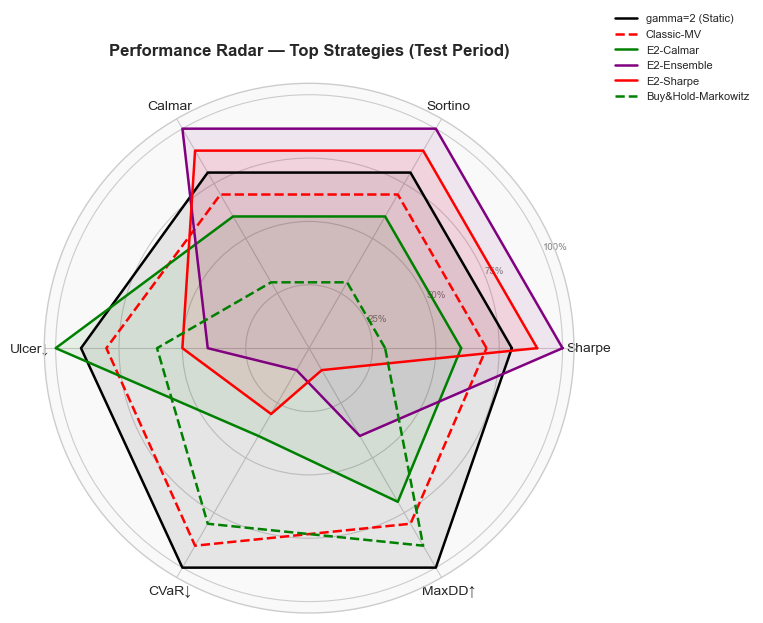


✓ Enhanced Analysis (13A–13H) SELESAI.
  Output dir: g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean2\ablation_results_thesis


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# 13H. Final Scorecard — Composite Rank (Thesis Summary Table)
# ═══════════════════════════════════════════════════════════════════════
# Rank tiap strategi di setiap metrik, hitung rank komposit.

score_rows = []
for exp_id in all_strategy_ids:
    avg_ret = results_test[exp_id].mean(axis=1)
    m = calculate_all_metrics(avg_ret)
    score_rows.append({
        'exp_id'   : exp_id,
        'Strategy' : get_display_name(exp_id),
        'Sharpe'   : m['Sharpe Ratio'],
        'Sortino'  : m['Sortino Ratio'],
        'Calmar'   : m['Calmar Ratio'],
        'CVaR'     : m['CVaR (95%)'],      # lower = better
        'MaxDD'    : m['Max Drawdown'],    # less negative = better
        'AnnRet'   : m['Ann. Return'],
        'AnnVol'   : m['Ann. Volatility'], # lower = better (risk)
        'Ulcer'    : m['Ulcer Index'],     # lower = better
    })

df_sc = pd.DataFrame(score_rows)

# Rank (1 = best)
df_sc['R_Sharpe']  = df_sc['Sharpe'].rank(ascending=False)
df_sc['R_Sortino'] = df_sc['Sortino'].rank(ascending=False)
df_sc['R_Calmar']  = df_sc['Calmar'].rank(ascending=False)
df_sc['R_CVaR']    = df_sc['CVaR'].rank(ascending=True)   # lower CVaR = better
df_sc['R_MaxDD']   = df_sc['MaxDD'].rank(ascending=False)  # less negative = higher rank
df_sc['R_Ulcer']   = df_sc['Ulcer'].rank(ascending=True)   # lower = better
df_sc['Composite'] = (df_sc['R_Sharpe'] + df_sc['R_Sortino'] + df_sc['R_Calmar'] +
                      df_sc['R_CVaR']   + df_sc['R_MaxDD']   + df_sc['R_Ulcer']) / 6
df_sc = df_sc.sort_values('Composite')

print('\n=== FINAL COMPOSITE SCORECARD (Lower Composite Rank = Better) ===')
display(df_sc[['Strategy','Sharpe','Sortino','Calmar','CVaR','MaxDD','Ulcer','Composite']].round(4))

# ── Radar / Spider Chart ───────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

TOP_N   = 6
top_ids = df_sc['exp_id'].values[:TOP_N]
categories = ['Sharpe','Sortino','Calmar','Ulcer↓','CVaR↓','MaxDD↑']
N_cat      = len(categories)
angles     = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True}, facecolor='white')
ax.set_facecolor('#f9f9f9')

for exp_id in top_ids:
    row    = df_sc[df_sc['exp_id'] == exp_id].iloc[0]
    # Normalize ranks 0..1 (1 = best)
    n      = len(all_strategy_ids)
    vals   = [
        1 - (row['R_Sharpe']  - 1) / (n - 1),
        1 - (row['R_Sortino'] - 1) / (n - 1),
        1 - (row['R_Calmar']  - 1) / (n - 1),
        1 - (row['R_Ulcer']   - 1) / (n - 1),
        1 - (row['R_CVaR']    - 1) / (n - 1),
        1 - (row['R_MaxDD']   - 1) / (n - 1),
    ]
    vals  += vals[:1]
    color  = ABLATION_COLORS.get(exp_id, '#777777')
    ls     = ABLATION_LINESTYLES.get(exp_id, '-')
    ax.plot(angles, vals, color=color, linestyle=ls, linewidth=1.8, label=get_display_name(exp_id))
    if ls == '-':
        ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='grey')
ax.set_title('Performance Radar — Top Strategies (Test Period)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '13H_radar_chart.png'), dpi=200)
plt.show()
plt.close()
print('\n✓ Enhanced Analysis (13A–13H) SELESAI.')
print(f'  Output dir: {OUTPUT_DIR}')



## 14. Thesis-Grade Sharpening — Statistical Rigor, Generalization & Interpretability

Penambahan terakhir untuk memperkuat klaim thesis secara akademis:
- **14A** Diebold-Mariano Test — uji signifikansi forecast loss antar strategi
- **14B** Walk-Forward Validation (expanding window) — anti data snooping
- **14C** Gamma Distribution Analysis — visualisasi distribusi aksi RL
- **14D** Concentration & HHI Analysis — seberapa terdiversifikasi portofolio
- **14E** Information Ratio vs Benchmark — metrik standar fund management
- **14F** Cross-Seed Stability Test — apakah hasil stabil di berbagai seed?
- **14G** Efficient Frontier Overlay — posisi strategi di peta risk-return
- **14H** LaTeX-Ready Summary Table — siap paste ke thesis



=== Diebold-Mariano Test vs Classic-MV (Test Period) ===
Strategy                 DM Stat   p-value       d_bar   Sig
----------------------------------------------------------
E2-Sharpe                 -2.348    0.0199   -0.000332    **
E2-Sortino                -2.282    0.0236   -0.000361    **
E2-Calmar                 -2.039    0.0428   -0.000285    **
E2-Ulcer                  -2.194    0.0294   -0.000346    **
E2-Ensemble               -2.196    0.0293   -0.000353    **
gamma=2 (Static)           0.675    0.5008    0.000027      
Buy&Hold-Markowitz        -0.341    0.7333   -0.000029      
Equal-Weight (Reb)        -2.701    0.0075   -0.000217   ***
Equal Weight              -2.701    0.0075   -0.000217   ***
Inv. Volatility           -2.544    0.0117   -0.000171    **
Sig codes: *** p<0.01  ** p<0.05  * p<0.10


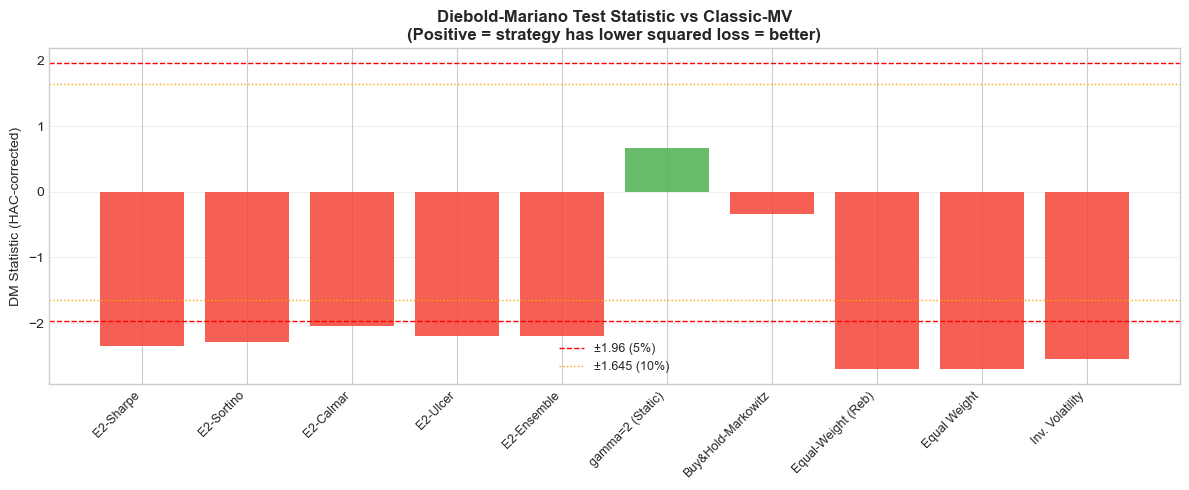

14A Diebold-Mariano selesai.


In [21]:
# ═══════════════════════════════════════════════════════════════════════
# 14A. Diebold-Mariano (DM) Test — Forecast Loss Significance
# ═══════════════════════════════════════════════════════════════════════
# DM test membandingkan squared loss antar dua strategi.
# H0: loss difference tidak signifikan.
# Lebih tepat daripada Wilcoxon untuk time-series karena memperhitungkan
# autokorelasi loss differential (Harvey, Leybourne, Newbold 1997).

from scipy.stats import t as t_dist

def diebold_mariano_test(ret1, ret2, h=1):
    """
    DM test dengan HAC (Newey-West) variance estimator.
    ret1, ret2: array return dua strategi (aligned).
    h: forecast horizon (1 = 1-step-ahead).
    Returns: (DM statistic, p-value, d_bar).
    """
    e1 = -np.array(ret1)   # loss = negative return
    e2 = -np.array(ret2)
    d  = e1**2 - e2**2     # squared loss differential
    n  = len(d)
    d_bar = d.mean()

    # Newey-West long-run variance
    gamma0 = np.var(d, ddof=1)
    nw_var = gamma0
    for lag in range(1, h):
        gamma_l = np.cov(d[lag:], d[:-lag])[0,1]
        nw_var += 2 * (1 - lag / h) * gamma_l
    nw_var = max(nw_var, 1e-12)

    dm_stat = d_bar / np.sqrt(nw_var / n)
    # Harvey et al. correction
    k       = (n + 1 - 2*h + h*(h-1)/n) / n
    dm_adj  = dm_stat * np.sqrt(k)
    pval    = 2 * t_dist.sf(abs(dm_adj), df=n-1)
    return float(dm_adj), float(pval), float(d_bar)


baseline_id_dm = 'Classic-MV'
base_ret       = results_test[baseline_id_dm].mean(axis=1)

dm_rows = []
print(f'\n=== Diebold-Mariano Test vs {baseline_id_dm} (Test Period) ===')
print(f'{"Strategy":<22}  {"DM Stat":>8}  {"p-value":>8}  {"d_bar":>10}  {"Sig":>4}')
print('-' * 58)
for exp_id in all_strategy_ids:
    if exp_id == baseline_id_dm:
        continue
    cmp_ret = results_test[exp_id].mean(axis=1)
    common  = base_ret.index.intersection(cmp_ret.index)
    try:
        dm, pv, db = diebold_mariano_test(base_ret.loc[common].values,
                                          cmp_ret.loc[common].values)
        sig = '***' if pv < 0.01 else ('**' if pv < 0.05 else ('*' if pv < 0.10 else ''))
        dm_rows.append({'Strategy': get_display_name(exp_id),
                        'DM Stat': dm, 'p-value': pv,
                        'd_bar (loss diff)': db, 'Sig': sig})
        print(f'{get_display_name(exp_id):<22}  {dm:>8.3f}  {pv:>8.4f}  {db:>10.6f}  {sig:>4}')
    except Exception as ex:
        print(f'{get_display_name(exp_id):<22}  ERROR: {ex}')

print('Sig codes: *** p<0.01  ** p<0.05  * p<0.10')
df_dm = pd.DataFrame(dm_rows)

# Plot DM statistics
if len(df_dm):
    fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')
    colors_dm = ['#F44336' if v < 0 else '#4CAF50' for v in df_dm['DM Stat']]
    ax.bar(range(len(df_dm)), df_dm['DM Stat'], color=colors_dm, alpha=0.85)
    ax.axhline( 1.96, color='red',   linestyle='--', linewidth=1, label='±1.96 (5%)')
    ax.axhline(-1.96, color='red',   linestyle='--', linewidth=1)
    ax.axhline( 1.645,color='orange',linestyle=':',  linewidth=1, label='±1.645 (10%)')
    ax.axhline(-1.645,color='orange',linestyle=':',  linewidth=1)
    ax.set_xticks(range(len(df_dm)))
    ax.set_xticklabels(df_dm['Strategy'], rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Diebold-Mariano Test Statistic vs {baseline_id_dm}\n'
                 '(Positive = strategy has lower squared loss = better)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('DM Statistic (HAC-corrected)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '14A_diebold_mariano.png'), dpi=200)
    plt.show()
    plt.close()
print('14A Diebold-Mariano selesai.')



=== Walk-Forward Sharpe Ratio per Fold ===


,E2-Sharpe,E2-Sortino,E2-Calmar,E2-Ulcer,E2-Ensemble,gamma=2 (Static),Buy&Hold-Markowitz,Equal-Weight (Reb),Classic-MV,Equal Weight,Inv. Volatility
Fold 1 (2019-04-02–2019-05-20),12.861,9.740,7.354,12.548,11.992,11.736,8.152,9.354,11.399,9.354,9.184
Fold 2 (2019-05-21–2019-07-08),2.265,2.569,2.491,2.381,2.667,1.424,1.082,0.739,1.243,0.739,0.948
Fold 3 (2019-07-09–2019-08-26),-1.291,-1.198,-1.242,-1.323,-1.262,-1.474,-1.331,-1.347,-1.424,-1.347,-1.359
Fold 4 (2019-08-27–2019-10-17),-1.107,-1.165,-1.067,-1.024,-0.998,-1.213,-1.352,-1.096,-1.231,-1.096,-1.113


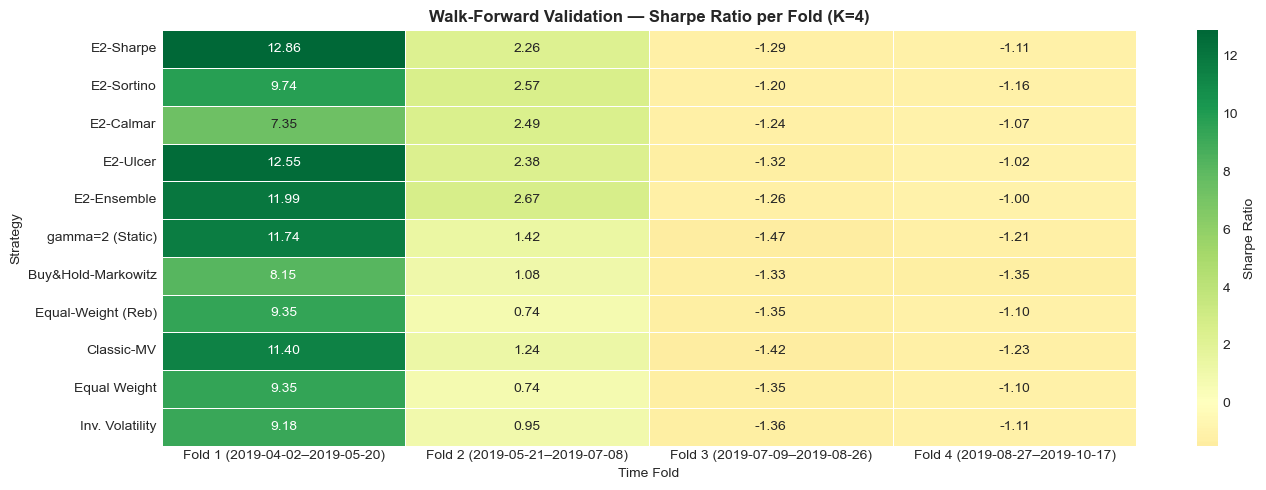


=== Cross-Fold Stability (CV = Std/|Mean|, lower = more stable) ===


,Strategy,Mean Sharpe,Std Sharpe,Stability (CV)
0,E2-Sharpe,3.181976,5.764464,1.812
3,E2-Ulcer,3.145820,5.620177,1.787
4,E2-Ensemble,3.099778,5.363684,1.730
5,gamma=2 (Static),2.618410,5.384932,2.057
8,Classic-MV,2.496631,5.246505,2.101
1,E2-Sortino,2.486483,4.458912,1.793
10,Inv. Volatility,1.914943,4.291280,2.241
7,Equal-Weight (Reb),1.912391,4.371081,2.286
9,Equal Weight,1.912391,4.371081,2.286
2,E2-Calmar,1.884160,3.491820,1.853


14B Walk-Forward Validation selesai.


In [22]:
# ═══════════════════════════════════════════════════════════════════════
# 14B. Walk-Forward Out-of-Sample Validation (Expanding Window)
# ═══════════════════════════════════════════════════════════════════════
# Membagi data test menjadi K fold berurutan (time-ordered).
# Model di-evaluate pada setiap fold tanpa re-train.
# Menunjukkan apakah performa stabil dari waktu ke waktu (anti-snooping).

K_FOLDS = 4   # jumlah fold waktu

def walk_forward_eval(exp_id, k_folds=K_FOLDS):
    """
    Bagi test period ke k_folds fold temporal berurutan.
    Kembalikan list metrik per fold.
    """
    all_idx  = list(range(SET_WINDOW, len(ret_test)))
    fold_sz  = len(all_idx) // k_folds
    fold_metrics = []

    for k in range(k_folds):
        start = k * fold_sz
        end   = (k + 1) * fold_sz if k < k_folds - 1 else len(all_idx)
        fold_idx = all_idx[start:end]
        if len(fold_idx) < 5:
            continue

        avg_ret = results_test[exp_id].mean(axis=1)
        fold_dates = ret_test.index[fold_idx]
        sub = avg_ret.loc[avg_ret.index.isin(fold_dates)]
        if len(sub) < 5:
            continue

        m = calculate_all_metrics(sub)
        m['Fold']  = k + 1
        m['Start'] = str(fold_dates[0].date())
        m['End']   = str(fold_dates[-1].date())
        m['N']     = len(sub)
        fold_metrics.append(m)
    return fold_metrics


wf_results = {}
for exp_id in all_strategy_ids:
    wf_results[exp_id] = walk_forward_eval(exp_id)

# ── Heatmap Sharpe per fold ───────────────────────────────────────────────
wf_sharpe = pd.DataFrame({
    get_display_name(eid): [f['Sharpe Ratio'] for f in folds]
    for eid, folds in wf_results.items() if folds
})
wf_sharpe.index = [f'Fold {f["Fold"]} ({f["Start"]}–{f["End"]})' 
                   for f in list(wf_results.values())[0]]

print('\n=== Walk-Forward Sharpe Ratio per Fold ===')
display(wf_sharpe.round(3))

fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
sns.heatmap(wf_sharpe.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Sharpe Ratio'})
ax.set_title(f'Walk-Forward Validation — Sharpe Ratio per Fold (K={K_FOLDS})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Time Fold'); ax.set_ylabel('Strategy')
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig(os.path.join(OUTPUT_DIR, '14B_walk_forward_heatmap.png'), dpi=200)
plt.show()
plt.close()

# ── Stability: std dev of Sharpe across folds ─────────────────────────────
wf_stability = pd.DataFrame({
    'Strategy': [get_display_name(eid) for eid in all_strategy_ids if wf_results[eid]],
    'Mean Sharpe': [np.mean([f['Sharpe Ratio'] for f in wf_results[eid]])
                    for eid in all_strategy_ids if wf_results[eid]],
    'Std Sharpe' : [np.std([f['Sharpe Ratio'] for f in wf_results[eid]])
                    for eid in all_strategy_ids if wf_results[eid]],
}).sort_values('Mean Sharpe', ascending=False)
wf_stability['Stability (CV)'] = (wf_stability['Std Sharpe'] /
                                   wf_stability['Mean Sharpe'].abs().clip(1e-6)).round(3)
print('\n=== Cross-Fold Stability (CV = Std/|Mean|, lower = more stable) ===')
display(wf_stability)
print('14B Walk-Forward Validation selesai.')


  Skip BuyHold_Markowitz: ('BuyHold_Markowitz', 42)
  Skip EqualWeight: ('EqualWeight', 42)


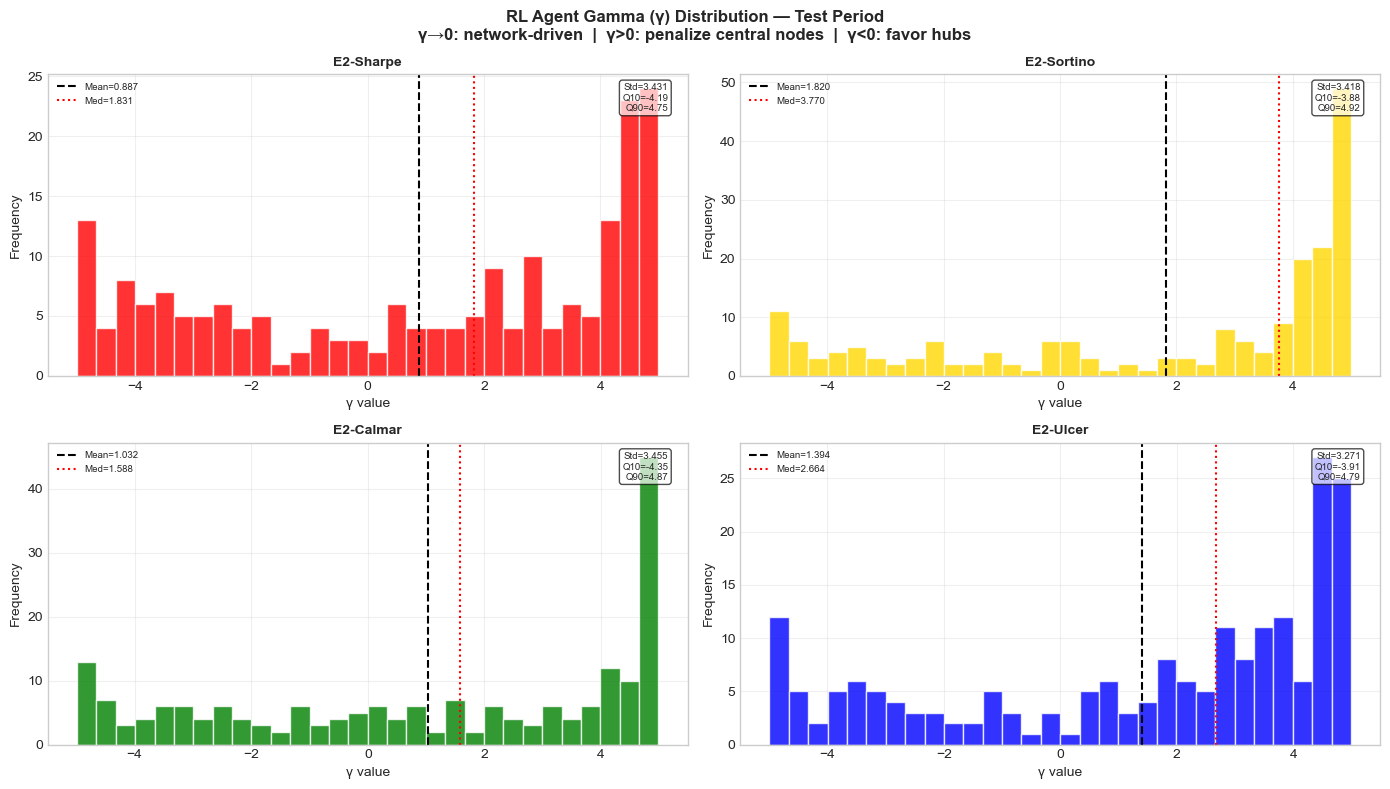

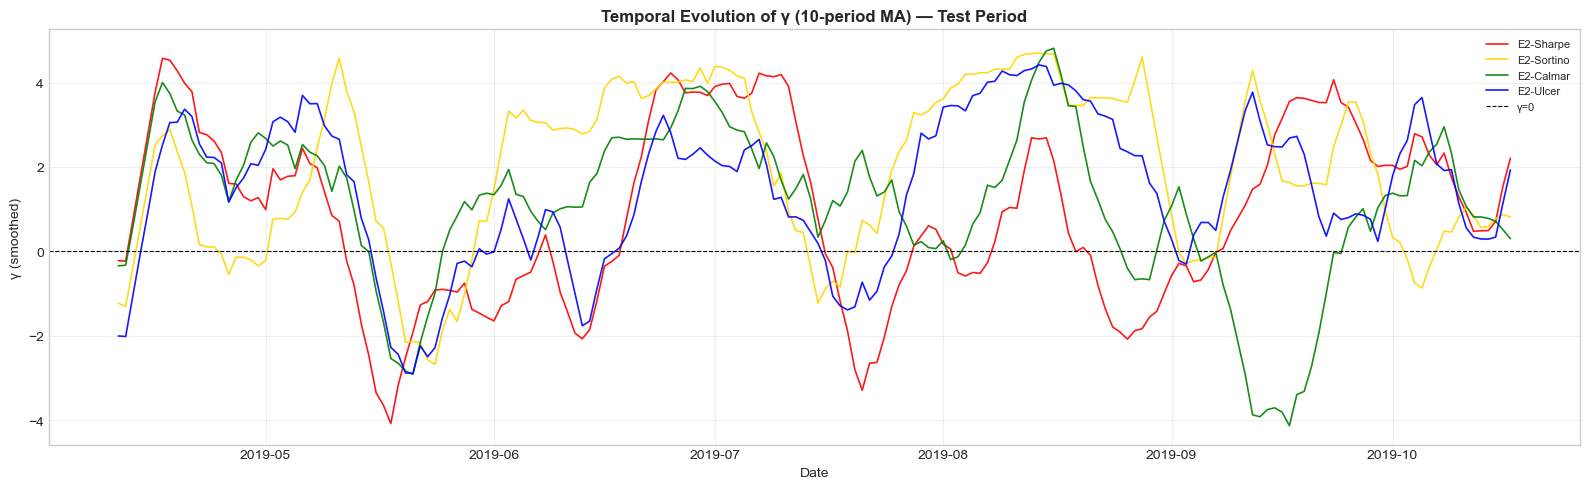

14C Gamma Distribution Analysis selesai.


In [23]:
# ═══════════════════════════════════════════════════════════════════════
# 14C. Gamma (Action) Distribution Analysis
# ═══════════════════════════════════════════════════════════════════════
# Visualisasi distribusi gamma yang dipilih RL agent selama test period.
# Menjawab: apakah agent belajar gamma yang stabil atau sangat fluktuatif?

rl_exp_ids = [eid for eid, cfg in ABLATION_CONFIGS.items()
              if cfg.get('static_gamma') is None and not cfg.get('is_ensemble')]

gamma_distributions = {}
for exp_id in rl_exp_ids:
    config = ABLATION_CONFIGS[exp_id]
    seed   = SEEDS[0]
    try:
        model = SAC.load(trained_models[(exp_id, seed)])
        gammas = []
        for i in range(SET_WINDOW, len(ret_test)):
            c = GLOBAL_CACHE[('test', i)]
            obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
            action, _ = model.predict(obs, deterministic=True)
            gammas.append(float(action[0]))
        gamma_distributions[exp_id] = np.array(gammas)
    except Exception as ex:
        print(f'  Skip {exp_id}: {ex}')

if gamma_distributions:
    n_plots = len(gamma_distributions)
    fig, axes = plt.subplots(2, (n_plots+1)//2, figsize=(14, 8), facecolor='white')
    axes = axes.flatten()
    fig.suptitle('RL Agent Gamma (γ) Distribution — Test Period\n'
                 'γ→0: network-driven  |  γ>0: penalize central nodes  |  γ<0: favor hubs',
                 fontsize=12, fontweight='bold')

    for ax, (exp_id, gammas) in zip(axes, gamma_distributions.items()):
        color = ABLATION_COLORS.get(exp_id, '#777777')
        ax.hist(gammas, bins=30, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(gammas.mean(),  color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean={gammas.mean():.3f}')
        ax.axvline(np.median(gammas), color='red', linestyle=':', linewidth=1.5,
                   label=f'Med={np.median(gammas):.3f}')
        ax.set_title(get_display_name(exp_id), fontsize=10, fontweight='bold')
        ax.set_xlabel('γ value'); ax.set_ylabel('Frequency')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # Annotate stats
        stats_txt = (f'Std={gammas.std():.3f}\n'
                     f'Q10={np.percentile(gammas,10):.2f}\n'
                     f'Q90={np.percentile(gammas,90):.2f}')
        ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
                fontsize=7, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    for ax in axes[len(gamma_distributions):]:
        ax.set_visible(False)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '14C_gamma_distributions.png'), dpi=200)
    plt.show()
    plt.close()

    # ── Temporal gamma plot (time series of gamma choices) ─────────────────
    fig, ax = plt.subplots(figsize=(16, 5), facecolor='white')
    for exp_id, gammas in gamma_distributions.items():
        idx = ret_test.index[SET_WINDOW:SET_WINDOW+len(gammas)]
        ax.plot(idx, pd.Series(gammas, index=idx).rolling(10).mean(),
                label=get_display_name(exp_id),
                color=ABLATION_COLORS.get(exp_id, '#777777'), alpha=0.9, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='γ=0')
    ax.set_title('Temporal Evolution of γ (10-period MA) — Test Period',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('γ (smoothed)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '14C_gamma_temporal.png'), dpi=200)
    plt.show()
    plt.close()
print('14C Gamma Distribution Analysis selesai.')


